# Nielsen CSD Preprocessing — EDA & Parameter Analysis

## PURPOSE
Canonical Exploratory Data Analysis to validate and justify feature engineering parameters
for CSD Nielsen preprocessing. Generates all parameters (MIN_PERIODS, LAGS, ROLLING_WINDOWS,
HOLIDAY_MONTHS, TRAIN_END, VAL_END) via empirical analysis. Serves as template for Phase 5
replication (Energidrikke, Danskvand, RTD).

ANALYSIS INCLUDES:
  - Data distribution analysis (histograms with skewness, ECDF)
  - Time series decomposition (trend, seasonal, residual)
  - Autocorrelation structure (ACF/PACF, lag analysis)
  - Stationarity testing (ADF test)
  - Correlation analysis (metric relationships)
  - Brand-level analysis (top brands, behavioral differences)
  - Outlier detection (anomaly identification)
  - Categorical breakdown (promo intensity)

## VISUALIZATION PHILOSOPHY
All plots follow best practices:
- Rossmann color scheme (#386B7F primary, plasma categorical)
- GeeksforGeeks methodology (histograms with skewness, faceted plots)
- Seaborn styling (clean grids, professional appearance)
- High DPI (150) for thesis appendix quality
- Clear titles, axis labels, and interpretation guides

## OUTPUT
EDA findings saved to: csd_eda_findings.json
Beautiful PNG plots saved to: csd_eda_plots/ (14 visualizations)


## Step 0: Settings & Configurations

### Step 0.1 - Pip Installs & Imports

In [1]:
%pip install --upgrade pip
%pip install statsmodels
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# System imports
import sys
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# Datatypes Import
import json

# Data Science Imports
import statsmodels
import matplotlib
try:
    # Jupyter kernel: render plots inline under each cell, no blocking window.
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    # Plain-script context (no IPython kernel, e.g. this notebook run via
    # nbconvert/python directly): fall back to a non-interactive backend so
    # plt.show() is a no-op instead of opening a blocking OS window.
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensuring Specific Modules Imported
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

### Step 0.2 - Find Root Path

In [3]:
# ============================================================================
# PROJECT INITIALIZATION
# ============================================================================

current = Path.cwd()
while current != current.parent:
	if (current / "CLAUDE.md").exists():
		ROOT_DIR = current
		break
	current = current.parent
else:
	raise FileNotFoundError("Could not find project root (CLAUDE.md)")

sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "02_thesis_data" / "_02_preprocessing" / "nielsen" / "_shared_modules"))

from PATHS import get_category_pipeline_step_outputs_dir

### Step 0.3 - Paths & Config

In [4]:
# ============================================================================
# CONFIGURATION
# ============================================================================

CATEGORY = "CSD"
STEP_OUTPUT_DIR = get_category_pipeline_step_outputs_dir(CATEGORY)
# NOTE: no INPUT_AGGREGATE parquet read -- Steps 1-2 (cells above) already
# produced df in-memory. This notebook never reads step_1_aggregate.parquet.
OUTPUT_FINDINGS = STEP_OUTPUT_DIR / "csd_eda_findings.json"
OUTPUT_PLOTS_DIR = STEP_OUTPUT_DIR / "csd_eda_plots"
OUTPUT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Visualization configuration (Rossmann + GeeksforGeeks style)

sns.set(style="ticks")
sns.set_palette("husl")

PLOT_COLOR = '#386B7F'
PALETTE = 'plasma'
DPI = 150
FIGSIZE_DEFAULT = (12, 6)
FIGSIZE_LARGE = (14, 10)
FIGSIZE_XLARGE = (16, 12)

print(f"\n{'='*80}")
print(f"CSD Comprehensive Enhanced EDA Configuration")
print(f"{'='*80}")
print(f"  Category: {CATEGORY}")
print(f"  Output findings: {OUTPUT_FINDINGS}")
print(f"  Plots directory: {OUTPUT_PLOTS_DIR}")

# ============================================================================
# ML TARGET DEFINITION (C1 — must come before any lag/split/feature analysis)
# ============================================================================

# What we are predicting
TARGET_COL = "sales_units"          # raw column in the dataset
FORECAST_HORIZON = 1                # H=1: predict t+1 from features at t
LOG_TRANSFORM_TARGET = True         # Y = log1p(sales_units_{t+H}) — confirmed by ADF below

# Warmup: max lag or window needed before the first valid prediction row.
# Features use up to lag-13 and rolling-13, so the first 13 rows per brand
# produce NaN features and must be excluded from training / evaluation.
MAX_LAG = 13                        # lags: (1, 2, 3, 4, 8, 13)
MAX_WINDOW = 13                     # rolling windows: (4, 13)
WARMUP_PERIODS = max(MAX_LAG, MAX_WINDOW)   # = 13

print(f"ML TARGET DEFINITION")
print(f"  Y              = log1p({TARGET_COL}_{{t+{FORECAST_HORIZON}}})")
print(f"  Forecast horizon (H) = {FORECAST_HORIZON} month(s)")
print(f"  Log transform  = {LOG_TRANSFORM_TARGET}")
print(f"  Warmup buffer  = {WARMUP_PERIODS} periods (excluded from training start per brand)\n")

# ============================================================================


CSD Comprehensive Enhanced EDA Configuration
  Category: CSD
  Output findings: z:\_dev-ssd\thesis-manifold\02_thesis_data\_02_preprocessing\nielsen\CSD\pipeline_step_outputs\csd_eda_findings.json
  Plots directory: z:\_dev-ssd\thesis-manifold\02_thesis_data\_02_preprocessing\nielsen\CSD\pipeline_step_outputs\csd_eda_plots
ML TARGET DEFINITION
  Y              = log1p(sales_units_{t+1})
  Forecast horizon (H) = 1 month(s)
  Log transform  = True
  Warmup buffer  = 13 periods (excluded from training start per brand)



### Step 0.4 - Cache Validation

In [5]:
# ============================================================================
# STEP 0: VERIFY PARQUET CACHE
# ============================================================================
# Validates that Stage 1 (JSONL -> Parquet conversion) has produced the 4
# required Nielsen view parquet files for this category, before Step 1
# attempts to load/merge them. Validation only -- no files are written here.

from PATHS import THESIS_DATA_CONVERTED_NIELSEN_PARQUET_DIR

CACHE_VIEWS_DIR = THESIS_DATA_CONVERTED_NIELSEN_PARQUET_DIR / CATEGORY / "views"


def validate_parquet_cache(category: str, cache_dir: Path) -> dict:
	"""Validate that all required view parquet files exist in the cache."""
	required_view_files = [
		f"{category.lower()}_clean_facts_v.parquet",
		f"{category.lower()}_clean_dim_product_v.parquet",
		f"{category.lower()}_clean_dim_period_v.parquet",
		f"{category.lower()}_clean_dim_market_v.parquet",
	]

	missing = [f for f in required_view_files if not (cache_dir / f).exists()]
	found = [f for f in required_view_files if (cache_dir / f).exists()]

	if missing:
		return {
			"valid": False,
			"missing": missing,
			"found": found,
			"message": f"[{category}] Missing {len(missing)} of {len(required_view_files)} required parquet view files",
		}

	return {
		"valid": True,
		"missing": [],
		"found": found,
		"message": f"[{category}] All {len(required_view_files)} required parquet view files found",
	}


validation = validate_parquet_cache(CATEGORY, CACHE_VIEWS_DIR)

print()
print("=" * 80)
print("CACHE VERIFICATION SUMMARY")
print(f"{'='*80}")
print(f"Category: {CATEGORY}")
print(f"Cache location: {CACHE_VIEWS_DIR}")

if not validation["valid"]:
	print(f"Status: FAILED -- {validation['message']}")
	for f in sorted(validation["found"]):
		print(f"  found: {f}")
	for f in sorted(validation["missing"]):
		print(f"  MISSING: {f}")
	raise FileNotFoundError(
		f"Parquet cache incomplete for {CATEGORY}. Run Stage 1 (JSONL -> Parquet) first: "
		f"python 02_thesis_data/_00_raw/nielsen/jsonl_to_parquet/run_all_conversions.py --only {CATEGORY}"
	)

print(f"Status: OK -- {validation['message']}")
for f in sorted(validation["found"]):
	print(f"  {f}")
print(f"{'='*80}")


CACHE VERIFICATION SUMMARY
Category: CSD
Cache location: z:\_dev-ssd\thesis-manifold\02_thesis_data\_01_converted\nielsen\parquet_nielsen\CSD\views
Status: OK -- [CSD] All 4 required parquet view files found
  csd_clean_dim_market_v.parquet
  csd_clean_dim_period_v.parquet
  csd_clean_dim_product_v.parquet
  csd_clean_facts_v.parquet


# Step 1: Load Cached Parquet Files

In [6]:
# ============================================================================
# STEP 1: LOAD AND MERGE CACHED PARQUET VIEWS
# ============================================================================
# Loads the 4 Nielsen CSD view parquet files (validated by Step 0), merges
# them into a single row-level dataset, filters to the 9 mutually exclusive
# DVH EXCL. HD geographic regions, and filters to positive sales only.
# Transferred from pre_csd_1_load_and_aggregate.py's _load_merged().

import time

# 9 mutually exclusive geographic regions within DVH EXCL. HD scope.
# Excludes size tiers (Superettes/Small/Large/Hypermarkets) and rollups
# (EAST/WEST, national DVH EXCL. HD total) to prevent double-counting.
DVH_REGION_IDS = {
	1586000,  # DVH EXCL. HD - REG. 2 - KBH
	1585996,  # DVH EXCL. HD - REG. 1 - SJAELLAND NORD
	1586002,  # DVH EXCL. HD - REG. 3 - SJAELLAND SYD
	1647654,  # DVH EXCL. HD - REG. 4 - SJAELLAND VEST
	1586001,  # DVH EXCL. HD - REG. 5 - FYN
	1585998,  # DVH EXCL. HD - REG. 6 - SYD JYLLAND
	1586003,  # DVH EXCL. HD - REG. 7 - OEST JYLLAND
	1585997,  # DVH EXCL. HD - REG. 8 - NORD JYLLAND
	1585999,  # DVH EXCL. HD - REG. 9 - VEST JYLLAND
}


def _load_merged(parquet_dir):
	"""Load and merge the 4 Nielsen CSD view parquet files (grain-independent)."""
	print("  Loading view parquet files...")
	facts = pd.read_parquet(parquet_dir / "csd_clean_facts_v.parquet")
	products = pd.read_parquet(parquet_dir / "csd_clean_dim_product_v.parquet")
	periods = pd.read_parquet(parquet_dir / "csd_clean_dim_period_v.parquet")
	markets = pd.read_parquet(parquet_dir / "csd_clean_dim_market_v.parquet")

	print(f"  Facts shape: {facts.shape}")
	print(f"  Products shape: {products.shape}")
	print(f"  Periods shape: {periods.shape}")
	print(f"  Markets shape: {markets.shape}")

	merged = facts.merge(products[["product_id", "brand"]], on="product_id")
	merged = merged.merge(periods[["period_id", "period_year", "period_month"]], on="period_id")
	merged = merged.merge(markets[["market_id", "market_description"]], on="market_id")

	# Filter to the 9 mutually exclusive geographic regions within DVH EXCL. HD.
	merged = merged[merged["market_id"].isin(DVH_REGION_IDS)].copy()

	# Filter to positive sales only.
	merged = merged[merged["sales_units"] > 0].copy()

	return merged


print("=" * 80)
print("STEP 1: LOAD AND MERGE CACHED PARQUET VIEWS")
print("=" * 80)

_step1_start = time.perf_counter()
df_merged = _load_merged(CACHE_VIEWS_DIR)
_step1_elapsed = time.perf_counter() - _step1_start

print()
print(f"Merged row-level shape: {df_merged.shape}")
print(f"Unique brands: {df_merged['brand'].nunique()}")
print(f"Elapsed: {_step1_elapsed:.2f}s")
print("=" * 80)


STEP 1: LOAD AND MERGE CACHED PARQUET VIEWS
  Loading view parquet files...
  Facts shape: (9080538, 32)
  Products shape: (2103, 23)
  Periods shape: (44, 9)
  Markets shape: (86, 6)

Merged row-level shape: (243691, 36)
Unique brands: 140
Elapsed: 4.08s


# Step 2: Aggregate Dataset

In [7]:
# ============================================================================
# STEP 2: AGGREGATE TO BRAND x MONTH GRAIN
# ============================================================================
# Aggregates the merged row-level dataset to brand x period_year x period_month,
# summing sales/promo metrics and averaging weighted distribution.
# Transferred from pre_csd_1_load_and_aggregate.py's GRAIN_CONFIG + load_and_aggregate().
#
# GRAIN HISTORY: SRQ1 scope locked to brand x month only (2026-07-12); "bychain"
# and "byregion" grains are deferred (plans/P0027 Phase 4b).
#
# min_periods for "bymonth" (58/140 brands, 41.4%) was re-derived directly from
# the leakage-fixed brand x month rollup (140 brands, 44 months, non-zero-sales-
# month counts) -- the entry point into the "High" data-quality tier (>35
# non-zero months out of 44 possible). See pre_csd_1_load_and_aggregate.py's
# GRAIN_CONFIG comment block for full derivation history.

GRAIN = "bymonth"

GRAIN_CONFIG = {
	"bymonth": {
		"group_keys": ["brand"],
		"min_periods": 40,
		"min_periods_rationale": (
			"58/140 brands (41.4%) have >=40 non-zero sales-months out of 44 "
			"possible, the entry point into the 'High' data-quality tier "
			"(>35 non-zero months) per CSD EDA's brand-stability-analysis method, "
			"re-run against true brand x month grain (leakage-fixed, 2026-07-12)."
		),
	},
	"bychain": {
		"group_keys": ["brand", "chain_id"],
		"min_periods": None,  # not yet derived -- Phase 4b, deferred
	},
	"byregion": {
		"group_keys": ["brand", "market_id"],
		"min_periods": None,  # not yet derived -- Phase 4b, deferred
		"region_ids": DVH_REGION_IDS,
	},
}

IMPLEMENTED_GRAINS = {"bymonth"}


def load_and_aggregate(df_merged, grain):
	"""Aggregate the merged row-level dataset to the requested grain."""
	if grain not in GRAIN_CONFIG:
		raise ValueError(f"Unknown grain '{grain}'. Valid grains: {list(GRAIN_CONFIG)}")
	if grain not in IMPLEMENTED_GRAINS:
		raise NotImplementedError(
			f"Grain '{grain}' is not yet implemented for Step 2 aggregation. "
			f"See plans/P0027 Phase 4b (deferred, region/chain grains)."
		)

	agg_dict = {
		"sales_units": "sum",
		"sales_value": "sum",
		"sales_in_liters": "sum",
		"sales_units_any_promo": lambda x: sum(pd.Series(x).fillna(0)),
		"weighted_distribution": "mean",
	}

	if grain == "bymonth":
		aggregated = (
			df_merged.groupby(["brand", "period_year", "period_month"])
			.agg(agg_dict)
			.reset_index()
		)
		aggregated.columns = [
			"brand", "period_year", "period_month",
			"sales_units", "sales_value", "sales_liters", "promo_units", "weighted_dist",
		]

	return aggregated


print("=" * 80)
print(f"STEP 2: AGGREGATE TO {GRAIN.upper()} GRAIN")
print("=" * 80)

_step2_start = time.perf_counter()
df = load_and_aggregate(df_merged, GRAIN)
_step2_elapsed = time.perf_counter() - _step2_start

print()
print(f"Aggregated shape: {df.shape}")
print(f"Unique brands: {df['brand'].nunique()}")
if len(df) > 0:
	df_sorted = df.sort_values(["period_year", "period_month"])
	first, last = df_sorted.iloc[0], df_sorted.iloc[-1]
	print(f"Date range: {int(first.period_year)}-{int(first.period_month):02d} to {int(last.period_year)}-{int(last.period_month):02d}")
print(f"Elapsed: {_step2_elapsed:.2f}s")
print("=" * 80)
print()
print("Data preview:")
df.head(10)


STEP 2: AGGREGATE TO BYMONTH GRAIN

Aggregated shape: (3975, 8)
Unique brands: 140
Date range: 2022-10 to 2026-05
Elapsed: 0.39s

Data preview:


,brand,period_year,period_month,sales_units,sales_value,sales_liters,promo_units,weighted_dist
0,1724,2022,10,529.4180,9940.9647,105.8836,0.0,0.021969
1,1724,2022,11,434.4051,7950.7788,88.6810,0.0,0.017535
2,1724,2022,12,1079.0128,25086.9942,247.8026,0.0,0.019047
3,1724,2023,1,497.0000,11224.5100,112.8000,0.0,0.013207
4,1724,2023,2,542.9743,8479.1653,111.5949,0.0,0.014725
5,1724,2023,3,546.2940,10253.5437,115.2588,0.0,0.017050
6,1724,2023,4,360.6470,8901.0254,82.9294,0.0,0.012085
7,1724,2023,5,280.0000,7057.1240,65.0000,0.0,0.012534
8,1724,2023,6,541.9655,11791.1828,116.1931,0.0,0.015226
9,1724,2023,7,460.9655,9004.8828,95.1931,0.0,0.015710


# Step 3: Exploratory Data Analysis (EDA)

## Step 3.01 - Data Preview and Statistics


In [8]:
print("=" * 80)
print("CELL 1: Data Preview and Statistics")
print("=" * 80)

# df already produced in-memory by Step 2 (aggregation) -- no parquet read needed

# Display data shape and structure
info_df = pd.DataFrame({
	"Metric": ["Total Rows", "Unique Brands", "Columns"],
	"Value": [f"{len(df):,}", f"{df['brand'].nunique()}", f"{len(df.columns)}"]
})
print("\nData Shape:")
print(info_df.to_string(index=False))

# Column information with data quality
cols_info = pd.DataFrame({
	"Column": df.columns,
	"Data Type": df.dtypes.astype(str),
	"Non-Null": df.count(),
	"Missing": df.isnull().sum(),
	"Missing %": (100 * df.isnull().sum() / len(df)).round(1),
})
print("\nColumns & Data Quality:")
print(cols_info.to_string(index=False))

print("\nMissing Value Analysis:")
missing_df = cols_info[cols_info["Missing"] > 0][["Column", "Missing", "Missing %"]]
if len(missing_df) > 0:
	print(missing_df.to_string(index=False))
else:
	print("No missing values detected in key metrics")

print("\nSample Data (first 10 rows):")
print(df.head(10).to_string(index=False))

CELL 1: Data Preview and Statistics

Data Shape:
       Metric Value
   Total Rows 3,975
Unique Brands   140
      Columns     8

Columns & Data Quality:
       Column Data Type  Non-Null  Missing  Missing %
        brand       str      3975        0        0.0
  period_year     int64      3975        0        0.0
 period_month     int64      3975        0        0.0
  sales_units   float64      3975        0        0.0
  sales_value   float64      3975        0        0.0
 sales_liters   float64      3975        0        0.0
  promo_units   float64      3975        0        0.0
weighted_dist   float64      3975        0        0.0

Missing Value Analysis:
No missing values detected in key metrics

Sample Data (first 10 rows):
brand  period_year  period_month  sales_units  sales_value  sales_liters  promo_units  weighted_dist
 1724         2022            10     529.4180    9940.9647      105.8836          0.0       0.021969
 1724         2022            11     434.4051    7950.7788   

## Step 3.02 - Distribution Analysis with Skewness



CELL 2: Distribution Analysis with Skewness

✓ Skewness Analysis:
  period_year: Skewness = -0.034 → Approximately symmetric
  period_month: Skewness = 0.063 → Approximately symmetric
  sales_units: Skewness = 4.887 → Highly right-skewed (positive) — substantial non-normality (Kim, 2013) -> Log transform necessary
  sales_value: Skewness = 5.377 → Highly right-skewed (positive) — substantial non-normality (Kim, 2013) -> Log transform necessary
  sales_liters: Skewness = 5.200 → Highly right-skewed (positive) — substantial non-normality (Kim, 2013) -> Log transform necessary
  promo_units: Skewness = 0.000 → Approximately symmetric
  weighted_dist: Skewness = 1.695 → Right-skewed (positive) — Log transform justified


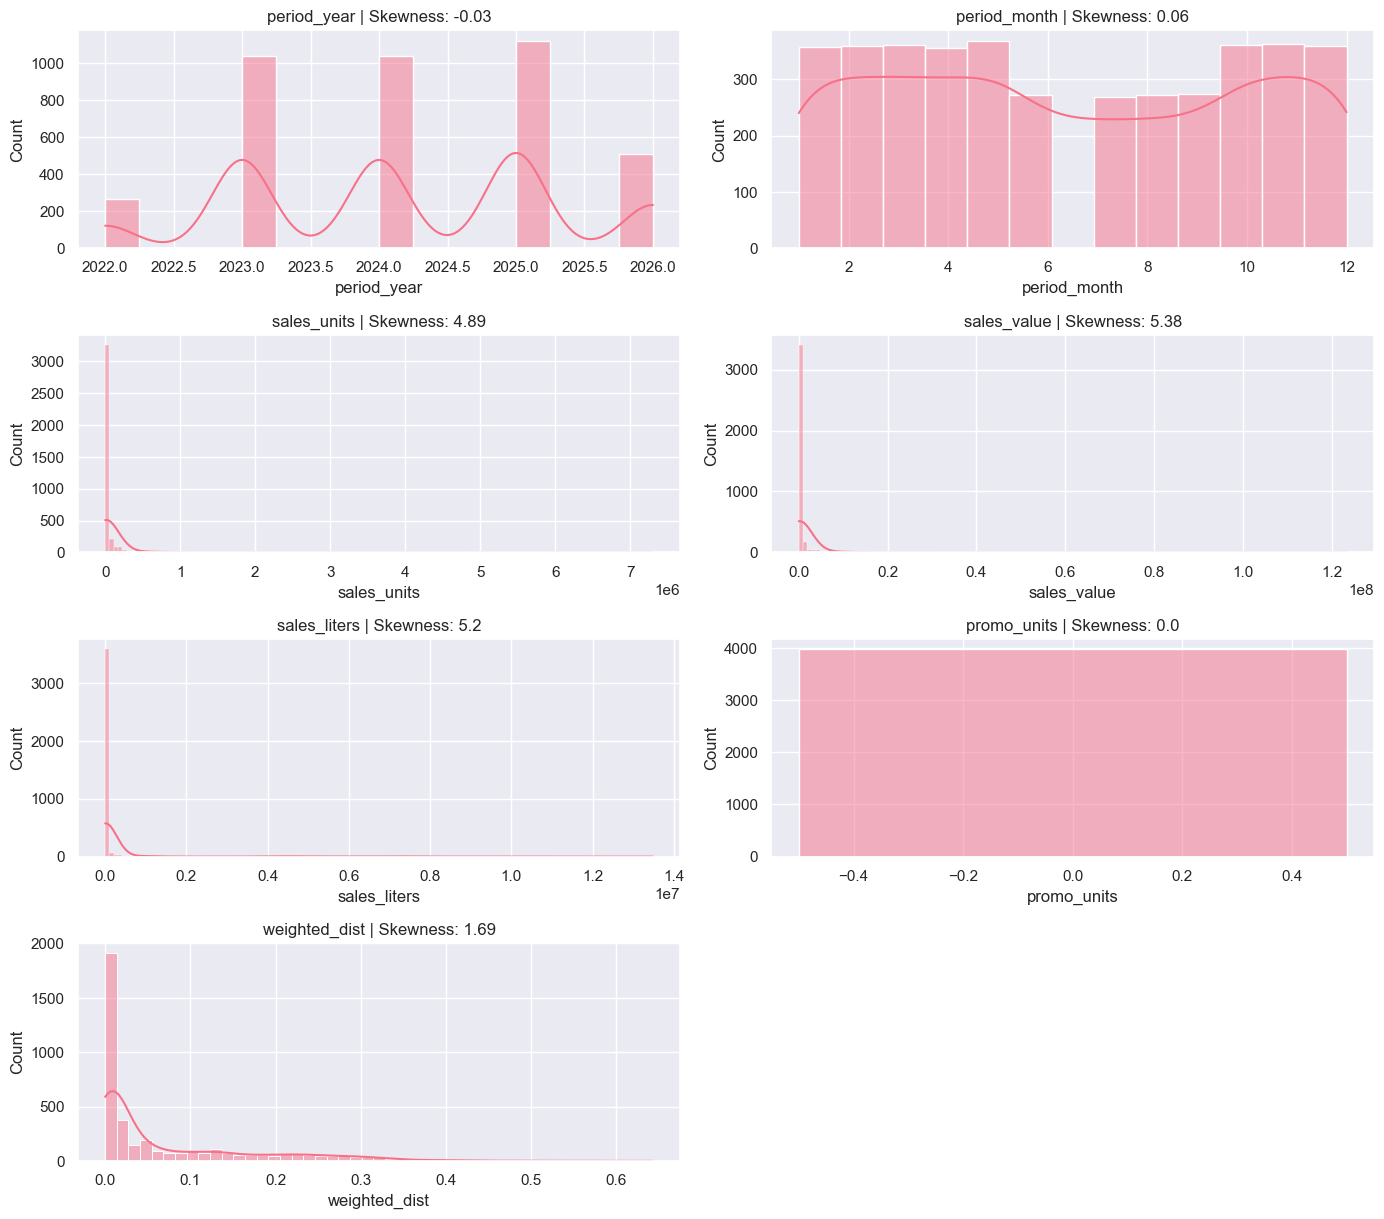

In [9]:
print("\n" + "=" * 80)
print("CELL 2: Distribution Analysis with Skewness")
print("=" * 80)

try:
		sns.set_style("darkgrid")
		numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

		plt.figure(figsize=(14, len(numerical_columns) * 3))

		print("\n✓ Skewness Analysis:")
		for idx, feature in enumerate(numerical_columns, 1):
				plt.subplot(len(numerical_columns), 2, idx)
				sns.histplot(df[feature], kde=True)
				skewness = df[feature].skew()
				plt.title(f"{feature} | Skewness: {round(skewness, 2)}")

				# Interpretation → Console output only
				# NOTE: extreme-negative branch must precede moderate-negative
				if skewness > 2:
					interp = "Highly right-skewed (positive) — substantial non-normality (Kim, 2013) -> Log transform necessary"
				elif skewness > 0.5:
					interp = "Right-skewed (positive) — Log transform justified"
				elif skewness < -2:
					interp = "Highly left-skewed (negative) - substantial non-normality (Kim, 2013) -> Log transform necessary"
				elif skewness < -0.5:
					interp = "Left-skewed (negative)"
				else:
					interp = "Approximately symmetric"

				print(f"  {feature}: Skewness = {skewness:.3f} → {interp}")

		plt.tight_layout()
		if OUTPUT_PLOTS_DIR.exists():
				plt.savefig(OUTPUT_PLOTS_DIR / "01_distribution_histograms.png", dpi=DPI, bbox_inches='tight')
		plt.show()

except Exception as e:
		print(f"⚠️   Distribution analysis failed: {e}")

## Step 3.03 - Date Range & Time Period Analysis


In [10]:
print("\n" + "=" * 80)
print("CELL 3: Date Range & Time Period Analysis")
print("=" * 80)

min_year = df['period_year'].min()
max_year = df['period_year'].max()
min_month = df[df['period_year'] == min_year]['period_month'].min()
max_month = df[df['period_year'] == max_year]['period_month'].max()

total_months = (max_year - min_year) * 12 + (max_month - min_month) + 1

# Coverage table
coverage_df = pd.DataFrame({
	"Metric": [
		"Date Range",
		"Total Months",
		"Total Rows",
		"Unique Brands",
		"Avg Rows/Brand",
	],
	"Value": [
		f"{min_year}-{min_month:02d} to {max_year}-{max_month:02d}",
		f"{total_months}",
		f"{len(df):,}",
		f"{df['brand'].nunique()}",
		f"{len(df) / df['brand'].nunique():.1f}",
	]
})
print("\n📈 Coverage:")
print(coverage_df.to_string(index=False))

# Rows per brand distribution
rows_per_brand = df.groupby('brand').size()
dist_df = pd.DataFrame({
	"Statistic": ["Min", "Max", "Mean", "Median", "Std Dev"],
	"Rows/Brand": [
		f"{rows_per_brand.min()}",
		f"{rows_per_brand.max()}",
		f"{rows_per_brand.mean():.1f}",
		f"{rows_per_brand.median():.0f}",
		f"{rows_per_brand.std():.1f}",
	]
})
print("\n📊 Rows per Brand Distribution:")
print(dist_df.to_string(index=False))


CELL 3: Date Range & Time Period Analysis

📈 Coverage:
        Metric              Value
    Date Range 2022-10 to 2026-05
  Total Months                 44
    Total Rows              3,975
 Unique Brands                140
Avg Rows/Brand               28.4

📊 Rows per Brand Distribution:
Statistic Rows/Brand
      Min          1
      Max         44
     Mean       28.4
   Median         34
  Std Dev       15.9


## Step 3.04 - Structural Break Scan (Auto-Detected)


In [11]:
print("\n" + "=" * 80)
print("CELL 3.04: STRUCTURAL BREAK SCAN (AUTO-DETECTED)")
print("=" * 80)

# Scan every candidate month (not a hardcoded COVID date) for a structural
# break in the aggregate monthly series: compare pre/post mean, std, and
# lag-1 autocorrelation, then rank candidates by a Chow-test F-statistic.
# This generalizes the old COVID-only check (invalid here since the CSD
# dataset starts 2022-10, well after COVID onset) to any candidate break,
# and runs early (right after date-range analysis) since a break materially
# changes how later cells (stationarity, seasonality, lag analysis) should
# be interpreted.

from scipy import stats as scipy_stats

monthly_agg = (
	df.groupby(["period_year", "period_month"])["sales_units"]
	.sum()
	.reset_index()
	.sort_values(["period_year", "period_month"])
	.reset_index(drop=True)
)
n_months = len(monthly_agg)
MIN_SEGMENT = 6  # need at least 6 months on each side for a meaningful test

candidates = []
if n_months < 2 * MIN_SEGMENT:
	print(f"\n  Only {n_months} months available -- too few to test for a structural break "
		  f"(need >= {2 * MIN_SEGMENT}). Skipping scan.")
	break_detected = False
else:
	sales_all = monthly_agg["sales_units"].values
	mean_all = sales_all.mean()
	rss_pooled = np.sum((sales_all - mean_all) ** 2)
	n_total = len(sales_all)
	k = 1  # intercept-only model

	for t in range(MIN_SEGMENT, n_months - MIN_SEGMENT):
		pre = sales_all[:t]
		post = sales_all[t:]
		rss_pre = np.sum((pre - pre.mean()) ** 2)
		rss_post = np.sum((post - post.mean()) ** 2)
		rss_split = rss_pre + rss_post
		if rss_split <= 0:
			continue
		chow_f = ((rss_pooled - rss_split) / k) / (rss_split / (n_total - 2 * k))
		chow_p = 1 - scipy_stats.f.cdf(chow_f, k, n_total - 2 * k)
		break_row = monthly_agg.iloc[t]
		candidates.append({
			"period_year": int(break_row["period_year"]),
			"period_month": int(break_row["period_month"]),
			"t": t,
			"chow_f": chow_f,
			"chow_p": chow_p,
			"mean_ratio": post.mean() / pre.mean() if pre.mean() > 0 else float("nan"),
			"std_ratio": post.std() / pre.std() if pre.std() > 0 else float("nan"),
		})

	cand_df = pd.DataFrame(candidates).sort_values("chow_f", ascending=False)
	top3 = cand_df.head(3)

	print(f"\n🔍 Scanned {len(candidates)} candidate break points across {n_months} months")
	print(f"   Top 3 candidates by Chow F-statistic:\n")
	display_df = top3.copy()
	display_df["date"] = display_df["period_year"].astype(str) + "-" + display_df["period_month"].astype(str).str.zfill(2)
	display_df["chow_f"] = display_df["chow_f"].round(2)
	display_df["chow_p"] = display_df["chow_p"].round(4)
	display_df["mean_ratio"] = display_df["mean_ratio"].round(3)
	display_df["std_ratio"] = display_df["std_ratio"].round(3)
	print(display_df[["date", "chow_f", "chow_p", "mean_ratio", "std_ratio"]].to_string(index=False))

	best = top3.iloc[0]
	break_detected = bool(best["chow_p"] < 0.05)
	if break_detected:
		print(f"\n  ⚠️  STRUCTURAL BREAK DETECTED at {int(best['period_year'])}-{int(best['period_month']):02d} "
			  f"(Chow F={best['chow_f']:.2f}, p={best['chow_p']:.4f})")
		print(f"  → Recommendation: add a binary 'post_break' feature at this date, "
			  f"or consider training separate models pre/post if severity warrants it")
	else:
		print(f"\n  ✓ No significant structural break detected (best candidate p={best['chow_p']:.4f} >= 0.05)")
		print(f"  → Pooled model across the full date range is statistically supportable")

print(f"\n✓ BREAK_DETECTED = {break_detected}")



CELL 3.04: STRUCTURAL BREAK SCAN (AUTO-DETECTED)

🔍 Scanned 32 candidate break points across 44 months
   Top 3 candidates by Chow F-statistic:

   date  chow_f  chow_p  mean_ratio  std_ratio
2023-12    1.85  0.1814       1.091      1.229
2024-03    1.84  0.1817       1.087      0.990
2024-05    1.65  0.2060       1.080      0.996

  ✓ No significant structural break detected (best candidate p=0.1814 >= 0.05)
  → Pooled model across the full date range is statistically supportable

✓ BREAK_DETECTED = False


## Step 3.05 - Stationarity Testing with ADF


In [12]:
print("\n" + "=" * 80)
print("CELL 4: Stationarity Testing — Per-Brand ADF Test")
print("=" * 80)

try:
	# Run ADF per brand so that the transform decision is per-brand, not aggregate.
	# A brand entering/exiting distribution has a structural break invisible in totals.
	print("\n🔍 Augmented Dickey-Fuller Test — per brand (top brands by volume)")
	print("   H0: non-stationary  |  p < 0.05 → stationary")
	print("   Testing: raw, log1p, first-difference\n")

	top_brands_for_adf = df.groupby('brand')['sales_units'].sum().nlargest(20).index

	adf_results = []
	for brand in top_brands_for_adf:
		series = (df[df['brand'] == brand]
					.sort_values(['period_year', 'period_month'])['sales_units']
					.fillna(0).values)
		if len(series) < 10:
			continue
		try:
			p_raw  = adfuller(series, autolag='AIC')[1]
			p_log  = adfuller(np.log1p(series), autolag='AIC')[1]
			p_diff = adfuller(np.diff(series), autolag='AIC')[1]
			stat_raw  = p_raw  < 0.05
			stat_log  = p_log  < 0.05
			stat_diff = p_diff < 0.05
			if stat_raw:
				rec = "raw"
			elif stat_log:
				rec = "log1p"
			else:
				rec = "log1p+diff"
			adf_results.append({
				"brand": brand[:30],
				"n": len(series),
				"p_raw": f"{p_raw:.3f}",
				"p_log": f"{p_log:.3f}",
				"p_diff": f"{p_diff:.3f}",
				"stat_raw": stat_raw,
				"stat_log": stat_log,
				"recommendation": rec,
			})
		except Exception:
			pass

	adf_df = pd.DataFrame(adf_results)
	display_cols = ["brand", "n", "p_raw", "p_log", "p_diff", "recommendation"]
	print(adf_df[display_cols].to_string(index=False))

	# Aggregate verdict across brands
	n_raw  = (adf_df['recommendation'] == 'raw').sum()
	n_log  = (adf_df['recommendation'] == 'log1p').sum()
	n_diff = (adf_df['recommendation'] == 'log1p+diff').sum()
	total_tested = len(adf_df)

	print(f"\n✓ CROSS-BRAND STATIONARITY SUMMARY ({total_tested} brands tested):")
	print(f"  Stationary raw:              {n_raw}/{total_tested} ({100*n_raw/total_tested:.0f}%)")
	print(f"  Stationary after log1p:      {n_log}/{total_tested} ({100*n_log/total_tested:.0f}%)")
	print(f"  Needs log1p + differencing:  {n_diff}/{total_tested} ({100*n_diff/total_tested:.0f}%)")

	# Decision rule: majority vote across brands
	if n_log + n_diff >= n_raw:
		log_necessary = True
		print(f"\n  → LOG TRANSFORM RECOMMENDED (majority of brands benefit)")
	else:
		log_necessary = False
		print(f"\n  → Log transform optional; raw series mostly stationary")
	print(f"  → LOG_TRANSFORM_TARGET = {log_necessary}")
	print(f"  Note: per-brand heterogeneity above — feature engineering should use log1p universally for stability")

	# Also run aggregate test for reference (not for decision)
	csd_monthly_values = df.groupby(['period_year', 'period_month'])['sales_units'].sum().values
	result_agg = adfuller(csd_monthly_values, autolag='AIC')
	print(f"\n  Aggregate series (reference only): ADF p={result_agg[1]:.4f} "
			f"{'(stationary)' if result_agg[1] < 0.05 else '(non-stationary)'}")
	print(f"  ⚠️  Aggregate result can mask per-brand heterogeneity — per-brand results above take precedence")

except Exception as e:
	print(f"⚠️  ADF test failed: {e}")
	log_necessary = None


CELL 4: Stationarity Testing — Per-Brand ADF Test

🔍 Augmented Dickey-Fuller Test — per brand (top brands by volume)
   H0: non-stationary  |  p < 0.05 → stationary
   Testing: raw, log1p, first-difference

            brand  n p_raw p_log p_diff recommendation
           HARBOE 44 0.918 0.919  0.001     log1p+diff
        COCA COLA 44 0.741 0.900  0.098     log1p+diff
            PEPSI 44 0.246 0.362  0.021     log1p+diff
       FAXE KONDI 44 0.011 0.000  0.118            raw
            FANTA 44 0.023 0.138  0.001            raw
            JOLLY 44 0.103 0.016  0.019          log1p
    TUBORG SQUASH 44 0.472 0.575  0.000     log1p+diff
        SCHWEPPES 44 0.000 0.083  0.000            raw
          HANCOCK 44 0.228 0.204  0.000     log1p+diff
       FEVER TREE 44 0.051 0.000  0.123          log1p
   SAN PELLEGRINO 44 0.382 0.001  0.000          log1p
     HARBOE OTHER 44 0.000 0.000  0.003            raw
              EGO 44 0.114 0.085  0.059     log1p+diff
           SPRITE 44 0

## Step 3.06 - Brand Stability Analysis (Series Length)


In [13]:
print("\n" + "=" * 80)
print("CELL 5: Brand Stability Analysis")
print("=" * 80)

non_zero_counts = df[df['sales_units'] > 0].groupby('brand').size()

# Brands at each threshold
thresholds = [20, 25, 30, 35, 40, 43]
stability_data = []
for threshold in thresholds:
	count = (non_zero_counts >= threshold).sum()
	pct = 100 * count / len(non_zero_counts)
	stability_data.append({
		"Min Periods": threshold,
		"Brands Retained": count,
		"% of Total": f"{pct:.1f}%",
		"Data Quality": "Low" if threshold <= 25 else ("Medium" if threshold <= 35 else "High")
	})

stability_df = pd.DataFrame(stability_data)
print("\n📊 Brand Retention at Different Thresholds:")
print(stability_df.to_string(index=False))

# THESIS-FOCUSED RECOMMENDATION
print("\n" + "🎯 THESIS-FOCUSED RECOMMENDATION: MIN_PERIODS = 40")
print("   ─" * 40)
brands_40 = (non_zero_counts >= 40).sum()
pct_40 = 100 * brands_40 / len(non_zero_counts)

recommendation_df = pd.DataFrame({
	"Aspect": [
		"Brands Retained",
		"Data Quality",
		"Coverage %",
		"Focus",
		"Rationale",
	],
	"Value": [
		f"{brands_40} brands",
		"High — 40+ periods each",
		f"{pct_40:.1f}%",
		"Proof-of-Concept (not production)",
		"Curate prompts to focus on well-documented brands for clean validation"
	]
})
print("\n" + recommendation_df.to_string(index=False))


CELL 5: Brand Stability Analysis

📊 Brand Retention at Different Thresholds:
 Min Periods  Brands Retained % of Total Data Quality
          20               87      62.1%          Low
          25               84      60.0%          Low
          30               77      55.0%       Medium
          35               67      47.9%       Medium
          40               58      41.4%         High
          43               57      40.7%         High

🎯 THESIS-FOCUSED RECOMMENDATION: MIN_PERIODS = 40
   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─

         Aspect                                                                  Value
Brands Retained                                                              58 brands
   Data Quality                                                High — 40+ periods each
     Coverage %                                                       

## Step 3.07 - Zero-Sales Characterisation


In [14]:
print("\n" + "=" * 80)
print("CELL 6: Zero-Sales Characterisation & Imputation Decision")
print("=" * 80)

# Distinguish run-of-zeros (brand entry/exit) vs scattered zeros (data gaps)
zero_analysis = []
for brand, grp in df.groupby('brand'):
    grp_sorted = grp.sort_values(['period_year', 'period_month'])
    sales = grp_sorted['sales_units'].values
    n_total = len(sales)
    n_zero = (sales == 0).sum()
    if n_zero == 0:
        zero_analysis.append({"brand": brand, "n_total": n_total, "n_zero": 0,
                               "pct_zero": 0.0, "type": "no zeros"})
        continue

    # Count zero runs (consecutive zero blocks)
    zero_mask = (sales == 0)
    run_lengths = []
    run = 0
    for v in zero_mask:
        if v:
            run += 1
        elif run > 0:
            run_lengths.append(run)
            run = 0
    if run > 0:
        run_lengths.append(run)

    max_run = max(run_lengths) if run_lengths else 0
    n_runs  = len(run_lengths)
    pct_zero = 100 * n_zero / n_total

    # Classify: clustered zeros = entry/exit; scattered = data gap
    if max_run >= 3:
        zero_type = "clustered (entry/exit)"
    elif n_runs > n_zero / 2:
        zero_type = "scattered (data gaps)"
    else:
        zero_type = "mixed"

    zero_analysis.append({
        "brand": brand, "n_total": n_total, "n_zero": int(n_zero),
        "pct_zero": round(pct_zero, 1), "max_run": int(max_run),
        "n_runs": int(n_runs), "type": zero_type,
    })

zero_df = pd.DataFrame(zero_analysis)
type_counts = zero_df['type'].value_counts()
total_brands = len(zero_df)

print(f"\nZero-sales characterisation across {total_brands} brands:")
print(type_counts.to_string())

brands_with_zeros = zero_df[zero_df['n_zero'] > 0]
print(f"\nBrands with any zeros: {len(brands_with_zeros)} / {total_brands}")
if len(brands_with_zeros) > 0:
    print(f"  Mean % zeros:   {brands_with_zeros['pct_zero'].mean():.1f}%")
    print(f"  Max run length: {brands_with_zeros['max_run'].max()} periods")

print(f"\n✓ Imputation strategy decision:")
print(f"  Clustered zeros (brand entry/exit) → exclude pre-entry periods; use distribution indicator feature")
print(f"  Scattered zeros (data gaps)        → forward-fill up to 2 periods; flag with missingness indicator")
print(f"  ⚠️  Rolling means must skip or fill zeros before computing — otherwise lags underestimate true trend")


CELL 6: Zero-Sales Characterisation & Imputation Decision

Zero-sales characterisation across 140 brands:
type
no zeros    140

Brands with any zeros: 0 / 140

✓ Imputation strategy decision:
  Clustered zeros (brand entry/exit) → exclude pre-entry periods; use distribution indicator feature
  Scattered zeros (data gaps)        → forward-fill up to 2 periods; flag with missingness indicator
  ⚠️  Rolling means must skip or fill zeros before computing — otherwise lags underestimate true trend


## Step 3.08 - Seasonal Pattern Analysis (Holiday Effect)


In [15]:
print("\n" + "=" * 80)
print("CELL 7: Seasonal Pattern Analysis (Holiday Effect)")
print("=" * 80)

# Monthly aggregation
monthly_sales = df.groupby('period_month')['sales_units'].sum()

# Create detailed monthly breakdown
monthly_data = []
for month in range(1, 13):
	if month in monthly_sales.index:
		sales = monthly_sales[month]
		pct = 100 * sales / monthly_sales.sum()
		monthly_data.append({
			"Month": month,
			"Month Name": ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][month-1],
			"Sales Units": f"{sales:,.0f}",
			"% of Total": f"{pct:.1f}%",
			"Classification": "★ PEAK" if pct >= 10 else ("Normal" if pct >= 8 else "Valley")
		})

monthly_df = pd.DataFrame(monthly_data)
print("\n📅 Monthly Sales Distribution (Full Year):")
print(monthly_df.to_string(index=False))

# Holiday analysis
top_3_months = monthly_sales.nlargest(3).index.tolist()
bottom_3_months = monthly_sales.nsmallest(3).index.tolist()
q75 = monthly_sales.quantile(0.75)
holiday_months = sorted([m for m in range(1, 13) if m in monthly_sales.index and monthly_sales[m] >= q75])

print(f"\n🔍 Peak & Valley Analysis:")
peak_valley_df = pd.DataFrame({
	"Category": ["Top 3 Months", "Bottom 3 Months", "Holiday Months (75th %ile)"],
	"Months": [str(top_3_months), str(bottom_3_months), str(holiday_months)],
	"% of Sales": [
		f"{100 * monthly_sales[top_3_months].sum() / monthly_sales.sum():.1f}%",
		f"{100 * monthly_sales[bottom_3_months].sum() / monthly_sales.sum():.1f}%",
		f"{100 * monthly_sales[holiday_months].sum() / monthly_sales.sum():.1f}%",
	]
})
print(peak_valley_df.to_string(index=False))

print(f"\n✓ Recommendation: HOLIDAY_MONTHS = {set(holiday_months)}")
print(f"   Rationale: Top 25% sales months (each ≥ {q75:,.0f} units)")


CELL 7: Seasonal Pattern Analysis (Holiday Effect)

📅 Monthly Sales Distribution (Full Year):
 Month Month Name Sales Units % of Total Classification
     1        Jan  56,007,538       6.7%         Valley
     2        Feb  67,467,917       8.0%         Normal
     3        Mar  88,650,717      10.6%         ★ PEAK
     4        Apr  68,865,203       8.2%         Normal
     5        May  76,179,587       9.1%         Normal
     6        Jun  72,181,323       8.6%         Normal
     7        Jul  49,961,230       6.0%         Valley
     8        Aug  55,167,371       6.6%         Valley
     9        Sep  68,893,937       8.2%         Normal
    10        Oct  65,383,378       7.8%         Valley
    11        Nov  66,629,488       7.9%         Valley
    12        Dec 103,818,475      12.4%         ★ PEAK

🔍 Peak & Valley Analysis:
                  Category     Months % of Sales
              Top 3 Months [12, 3, 5]      32.0%
           Bottom 3 Months  [7, 8, 1]      19.2%
Hol

## Step 3.09 - Monthly Sales Bar Plot



CELL 8: Monthly Sales Distribution (Bar Plot)


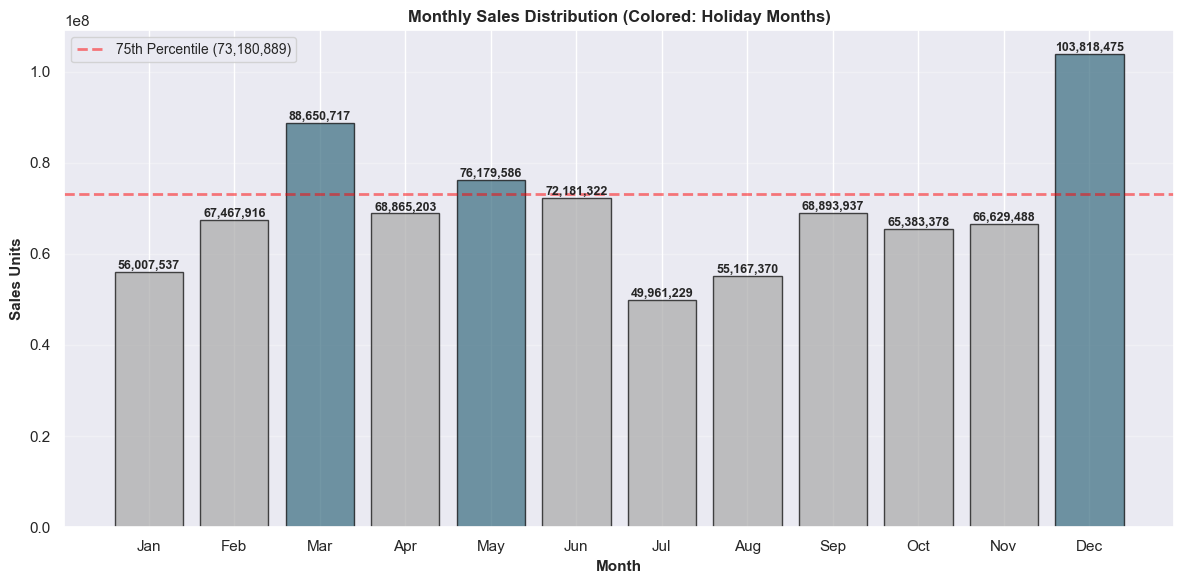


✓ Monthly Sales Visualization Complete
  Peak months (dark): [3, 5, 12]
  Valley months (gray): [7, 8, 1]


In [16]:
print("\n" + "=" * 80)
print("CELL 8: Monthly Sales Distribution (Bar Plot)")
print("=" * 80)

try:
	fig, ax = plt.subplots(figsize=(12, 6))

	months = list(range(1, 13))
	month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
	sales_by_month = [monthly_sales.get(m, 0) for m in months]

	# Color bars: highlight holiday months
	colors = [PLOT_COLOR if m in holiday_months else '#A9A9A9' for m in months]

	bars = ax.bar(month_names, sales_by_month, color=colors, edgecolor='black', alpha=0.7)

	# Add value labels on bars
	for bar in bars:
		height = bar.get_height()
		ax.text(bar.get_x() + bar.get_width()/2., height,
				f'{int(height):,}',
				ha='center', va='bottom', fontsize=9, fontweight='bold')

	ax.set_xlabel('Month', fontsize=11, fontweight='bold')
	ax.set_ylabel('Sales Units', fontsize=11, fontweight='bold')
	ax.set_title('Monthly Sales Distribution (Colored: Holiday Months)', fontsize=12, fontweight='bold')
	ax.grid(True, alpha=0.3, axis='y')
	ax.axhline(q75, color='red', linestyle='--', alpha=0.5, linewidth=2, label=f'75th Percentile ({q75:,.0f})')
	ax.legend(fontsize=10)

	plt.tight_layout()
	if OUTPUT_PLOTS_DIR.exists():
		plt.savefig(OUTPUT_PLOTS_DIR / "03_monthly_sales_distribution.png", dpi=DPI, bbox_inches='tight')
	plt.show()

	print("\n✓ Monthly Sales Visualization Complete")
	print(f"  Peak months (dark): {holiday_months}")
	print(f"  Valley months (gray): {bottom_3_months}")

except Exception as e:
	print(f"⚠️  Monthly sales plot failed: {e}")

## Step 3.10 - Seasonal Decomposition



CELL 9: Seasonal Decomposition (Trend + Seasonal + Residual)

🔍 Decomposition model selection:
   Additive  residual variance: 5.29e+11
   Multiplicative residual var: 1.58e-03
   → Selected model: 'multiplicative' (lower residual variance)


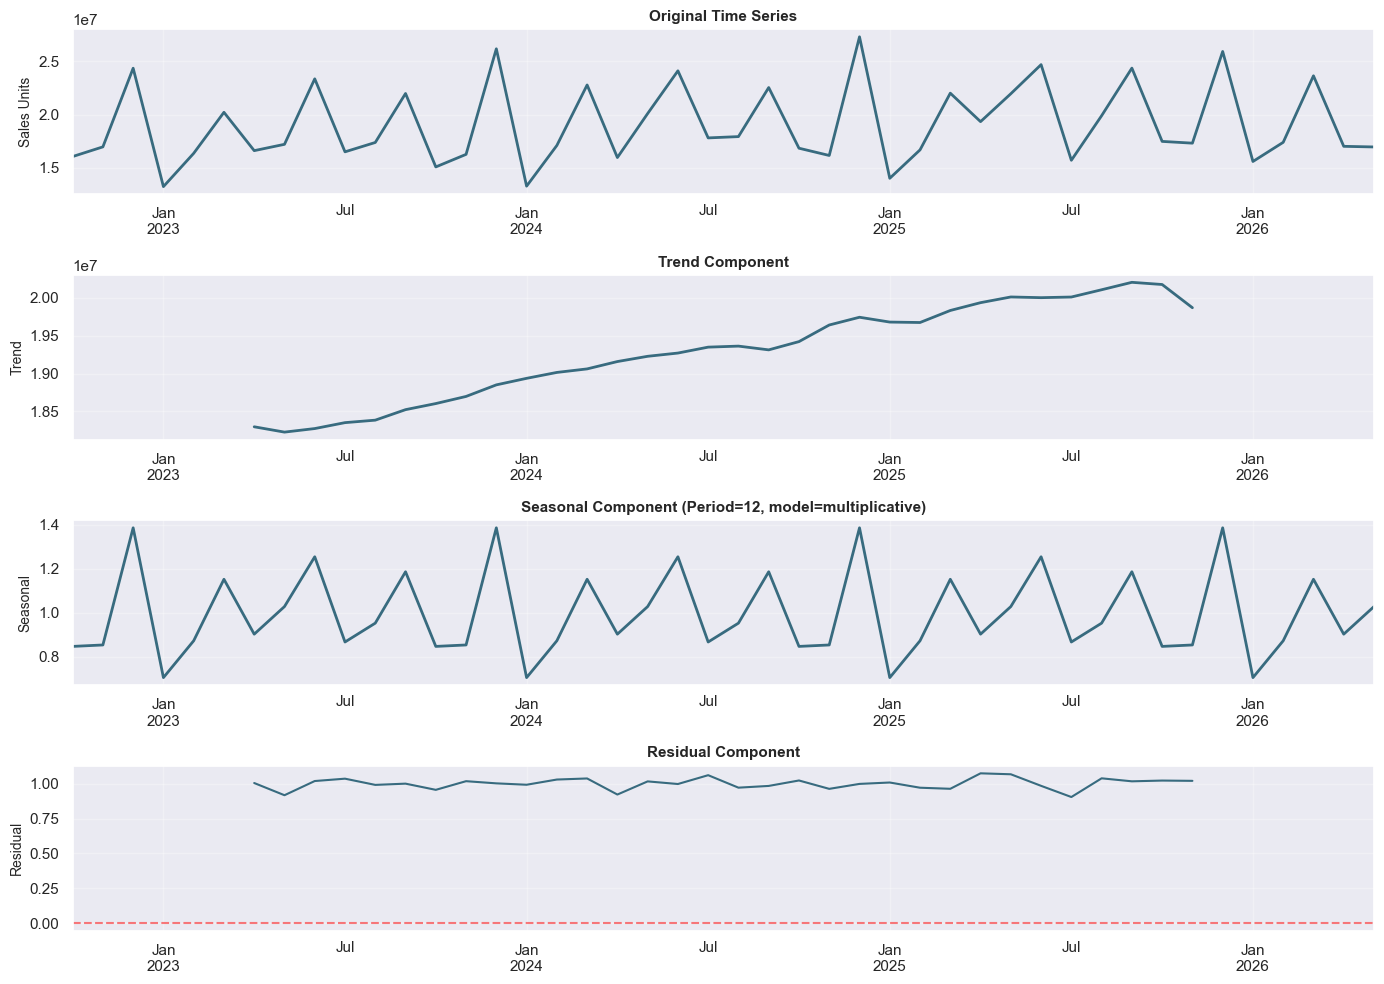


✓ Seasonal Decomposition Complete
  Trend: Decreasing over time
  Seasonal peaks (top 3 months): [12, 6, 9]
  → Validates HOLIDAY_MONTHS = {3, 12, 5}


In [17]:
print("\n" + "=" * 80)
print("CELL 9: Seasonal Decomposition (Trend + Seasonal + Residual)")
print("=" * 80)

try:
	# Aggregate all brands per (year, month) to get a full time series
	ts_raw = df.groupby(['period_year', 'period_month'])['sales_units'].sum().reset_index()
	ts_raw = ts_raw.sort_values(['period_year', 'period_month'])
	dates = pd.to_datetime(ts_raw[['period_year', 'period_month']].assign(day=1).rename(
		columns={'period_year': 'year', 'period_month': 'month'}))
	ts_monthly = pd.Series(ts_raw['sales_units'].values, index=dates)

	# Compare additive vs multiplicative to select the better model.
	# For FMCG data the seasonal amplitude often scales with trend volume
	# (multiplicative). Lower residual variance → better model fit.
	decomp_add  = seasonal_decompose(ts_monthly, model='additive',      period=12)
	decomp_mult = seasonal_decompose(ts_monthly, model='multiplicative', period=12)
	resid_var_add  = np.nanvar(decomp_add.resid)
	resid_var_mult = np.nanvar(decomp_mult.resid)
	best_model = 'additive' if resid_var_add <= resid_var_mult else 'multiplicative'
	decomposition  = decomp_add if best_model == 'additive' else decomp_mult

	print(f"\n🔍 Decomposition model selection:")
	print(f"   Additive  residual variance: {resid_var_add:.2e}")
	print(f"   Multiplicative residual var: {resid_var_mult:.2e}")
	print(f"   → Selected model: '{best_model}' (lower residual variance)")

	# Plot decomposition (Rossmann style)
	fig, axes = plt.subplots(4, 1, figsize=(14, 10))

	# Original
	ts_monthly.plot(ax=axes[0], color=PLOT_COLOR, linewidth=2)
	axes[0].set_ylabel('Sales Units', fontsize=10)
	axes[0].set_title('Original Time Series', fontsize=11, fontweight='bold')
	axes[0].grid(True, alpha=0.3)

	# Trend
	decomposition.trend.plot(ax=axes[1], color=PLOT_COLOR, linewidth=2)
	axes[1].set_ylabel('Trend', fontsize=10)
	axes[1].set_title('Trend Component', fontsize=11, fontweight='bold')
	axes[1].grid(True, alpha=0.3)

	# Seasonal
	decomposition.seasonal.plot(ax=axes[2], color=PLOT_COLOR, linewidth=2)
	axes[2].set_ylabel('Seasonal', fontsize=10)
	axes[2].set_title(f'Seasonal Component (Period=12, model={best_model})', fontsize=11, fontweight='bold')
	axes[2].grid(True, alpha=0.3)

	# Residual
	decomposition.resid.plot(ax=axes[3], color=PLOT_COLOR, linewidth=1.5)
	axes[3].set_ylabel('Residual', fontsize=10)
	axes[3].set_title('Residual Component', fontsize=11, fontweight='bold')
	axes[3].axhline(y=0, color='red', linestyle='--', alpha=0.5)
	axes[3].grid(True, alpha=0.3)

	plt.tight_layout()
	if OUTPUT_PLOTS_DIR.exists():
		plt.savefig(OUTPUT_PLOTS_DIR / "04_seasonal_decomposition.png", dpi=DPI, bbox_inches='tight')
	plt.show()

	# Extract seasonal peaks
	seasonal_by_month = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()
	seasonal_peaks = seasonal_by_month.nlargest(3)

	print("\n✓ Seasonal Decomposition Complete")
	print(f"  Trend: {'Increasing' if decomposition.trend.iloc[-1] > decomposition.trend.iloc[0] else 'Decreasing'} over time")
	print(f"  Seasonal peaks (top 3 months): {list(seasonal_peaks.index)}")
	print(f"  → Validates HOLIDAY_MONTHS = {set(holiday_months)}")

except Exception as e:
	print(f"⚠️  Seasonal decomposition failed: {e}")

## Step 3.11 - Top Brands Time Series



CELL 10: Top Brands Time Series Analysis

🏆 Top 5 Brands by Total Sales:
 Rank      Brand Total Sales
    1     HARBOE 203,143,311
    2  COCA COLA 194,849,514
    3      PEPSI 166,034,426
    4 FAXE KONDI 125,225,156
    5      FANTA  33,334,706


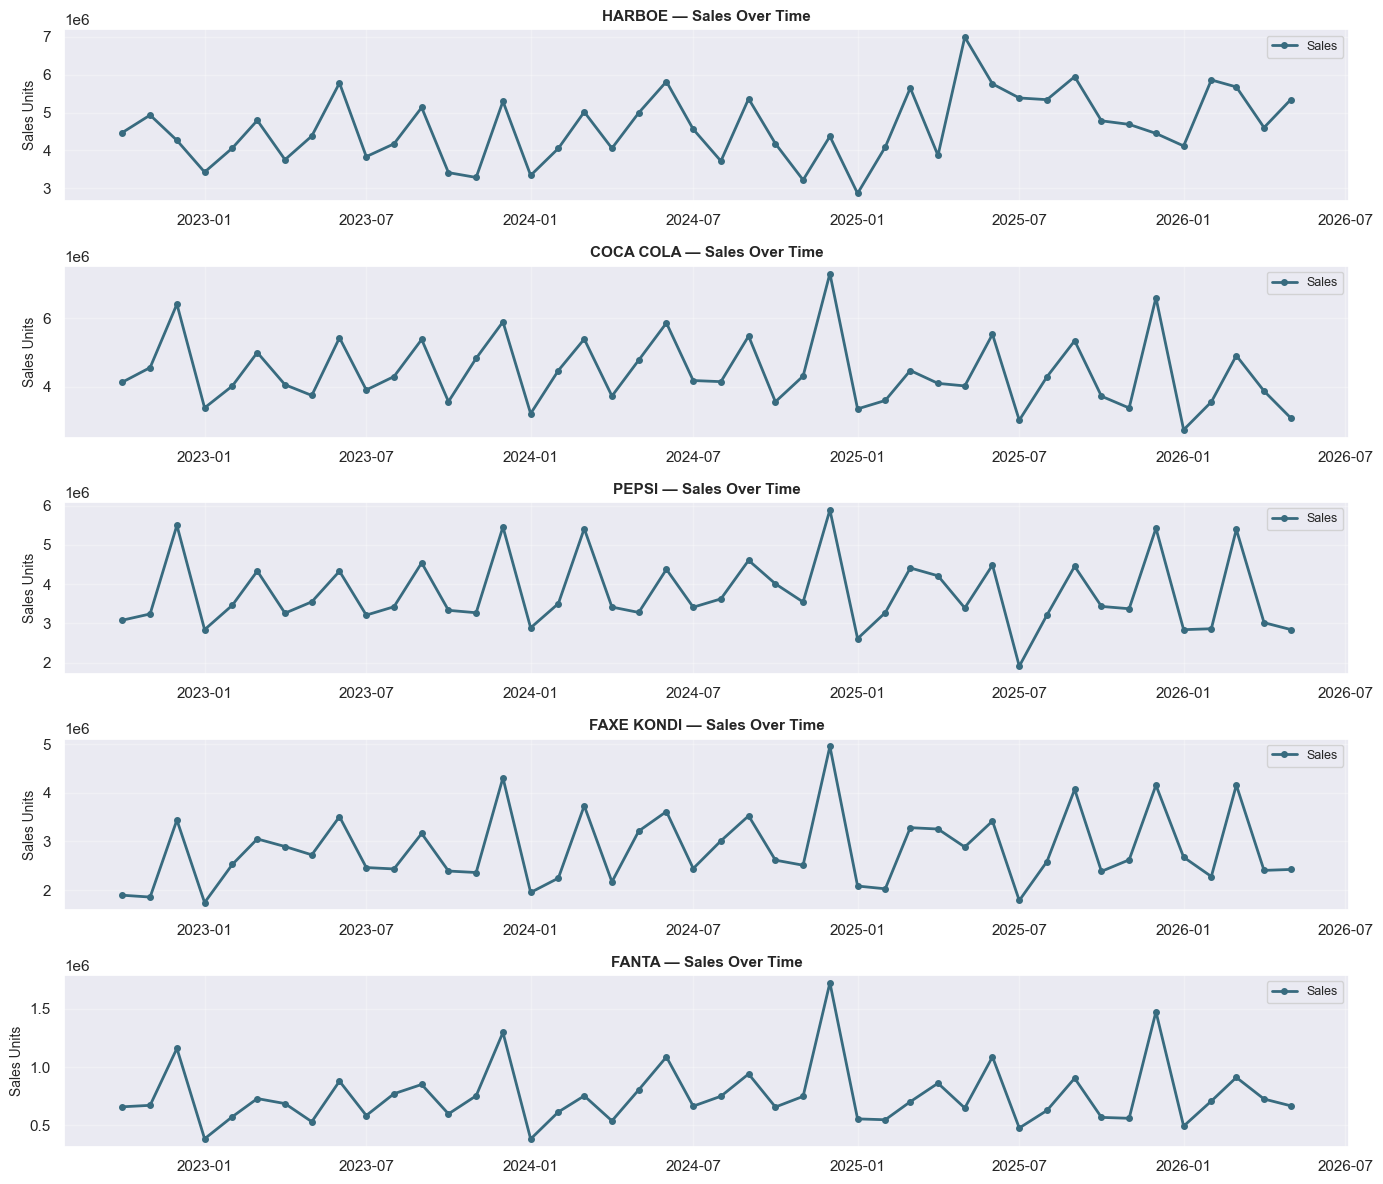


✓ Top Brands Time Series Complete
  Each plot shows temporal pattern for high-volume brands


In [18]:
print("\n" + "=" * 80)
print("CELL 10: Top Brands Time Series Analysis")
print("=" * 80)

try:
	top_brands = df.groupby('brand')['sales_units'].sum().nlargest(5).index
	print(f"\n🏆 Top 5 Brands by Total Sales:")
	top_brands_df = pd.DataFrame({
		"Rank": range(1, 6),
		"Brand": list(top_brands),
		"Total Sales": [f"{df[df['brand']==b]['sales_units'].sum():,.0f}" for b in top_brands]
	})
	print(top_brands_df.to_string(index=False))

	# Plot time series for top brands
	fig, axes = plt.subplots(5, 1, figsize=(14, 12))

	for idx, brand in enumerate(top_brands):
		brand_data = df[df['brand'] == brand].sort_values(['period_year', 'period_month']).copy()
		brand_data['date'] = pd.to_datetime(
			brand_data['period_year'].astype(str) + '-' +
			brand_data['period_month'].astype(str).str.zfill(2) + '-01'
		)
		brand_data = brand_data.sort_values('date')

		axes[idx].plot(brand_data['date'], brand_data['sales_units'],
						color=PLOT_COLOR, linewidth=2, marker='o', markersize=4, label='Sales')
		axes[idx].set_ylabel('Sales Units', fontsize=10)
		axes[idx].set_title(f'{brand} — Sales Over Time', fontsize=11, fontweight='bold')
		axes[idx].grid(True, alpha=0.3)
		axes[idx].legend(fontsize=9)

	plt.tight_layout()
	if OUTPUT_PLOTS_DIR.exists():
		plt.savefig(OUTPUT_PLOTS_DIR / "05_top_brands_timeseries.png", dpi=DPI, bbox_inches='tight')
	plt.show()

	print("\n✓ Top Brands Time Series Complete")
	print("  Each plot shows temporal pattern for high-volume brands")

except Exception as e:
	print(f"⚠️  Top brands time series failed: {e}")

## Step 3.12 - Cross-Brand Heterogeneity Analysis


In [19]:
print("\n" + "=" * 80)
print("CELL 11: Cross-Brand Heterogeneity Analysis")
print("=" * 80)

# Coefficient of variation (CV) per brand — measures sales dispersion
brand_stats = df.groupby('brand')['sales_units'].agg(['mean', 'std']).dropna()
brand_stats['cv'] = brand_stats['std'] / brand_stats['mean']
brand_stats = brand_stats[brand_stats['mean'] > 0]

print(f"\n📊 Sales Coefficient of Variation (CV = std/mean) across {len(brand_stats)} brands:")
cv_summary = pd.DataFrame({
    "Statistic": ["Min", "P25", "Median", "P75", "Max"],
    "CV": [
        f"{brand_stats['cv'].min():.3f}",
        f"{brand_stats['cv'].quantile(0.25):.3f}",
        f"{brand_stats['cv'].median():.3f}",
        f"{brand_stats['cv'].quantile(0.75):.3f}",
        f"{brand_stats['cv'].max():.3f}",
    ]
})
print(cv_summary.to_string(index=False))

high_cv_brands = (brand_stats['cv'] > 1.0).sum()
print(f"\n  Brands with CV > 1.0 (high volatility): {high_cv_brands} / {len(brand_stats)}")
print(f"  → High CV = sales pattern differs greatly across time → harder for single model")

# Peak month distribution per brand — do brands peak in the same months?
peak_month_per_brand = (df.groupby(['brand', 'period_month'])['sales_units']
                         .sum()
                         .groupby(level=0)
                         .idxmax()
                         .apply(lambda x: x[1]))  # extract month number

peak_month_dist = peak_month_per_brand.value_counts().sort_index()
month_names_short = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                     7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
print(f"\n📅 Distribution of brands' peak sales month:")
for month, count in peak_month_dist.items():
    bar = "█" * count
    print(f"  {month_names_short.get(month, month):>3}: {bar} ({count})")

peak_concentration = peak_month_dist.max() / peak_month_dist.sum()
print(f"\n  Peak-month concentration: {peak_concentration:.2f} (1.0 = all brands peak same month)")
if peak_concentration < 0.30:
    print("  → Brands peak in DIFFERENT months — seasonal features must be brand-specific")
else:
    print("  → Most brands share a peak month — shared seasonal feature is likely sufficient")

# Promo intensity spread across brands
sub_promo = df[df['promo_units'] > 0]
print(f"\n📦 Promo intensity spread across brands (mean per brand, where promo>0):")
if sub_promo.empty:
    print("  No promo activity recorded for this category at the region grain — skipping promo-intensity analysis.")
else:
    promo_by_brand = (sub_promo.groupby('brand')
                      .apply(lambda g: (g['promo_units'] / g['sales_units'].clip(lower=1)).mean()))
    promo_spread = pd.DataFrame({
        "Statistic": ["Min", "P25", "Median", "P75", "Max"],
        "Promo Intensity": [
            f"{promo_by_brand.min():.3f}",
            f"{promo_by_brand.quantile(0.25):.3f}",
            f"{promo_by_brand.median():.3f}",
            f"{promo_by_brand.quantile(0.75):.3f}",
            f"{promo_by_brand.max():.3f}",
        ]
    })
    print(promo_spread.to_string(index=False))
print(f"\n✓ Heterogeneity verdict:")
print(f"  High CV + varied peak months → consider brand fixed effects or per-brand models")
print(f"  Panel model (single model) viable only with brand embedding/categorical feature")


CELL 11: Cross-Brand Heterogeneity Analysis

📊 Sales Coefficient of Variation (CV = std/mean) across 136 brands:
Statistic    CV
      Min 0.000
      P25 0.500
   Median 0.773
      P75 1.155
      Max 4.822

  Brands with CV > 1.0 (high volatility): 45 / 136
  → High CV = sales pattern differs greatly across time → harder for single model

📅 Distribution of brands' peak sales month:
  Jan: ███████ (7)
  Feb: ████████ (8)
  Mar: ████████████████ (16)
  Apr: ███████ (7)
  May: ███████████ (11)
  Jun: ██████ (6)
  Jul: █████ (5)
  Aug: █████████ (9)
  Sep: █████ (5)
  Oct: ████████ (8)
  Nov: █████ (5)
  Dec: █████████████████████████████████████████████████████ (53)

  Peak-month concentration: 0.38 (1.0 = all brands peak same month)
  → Most brands share a peak month — shared seasonal feature is likely sufficient

📦 Promo intensity spread across brands (mean per brand, where promo>0):
  No promo activity recorded for this category at the region grain — skipping promo-intensity analys

## Step 3.13 - Lag Analysis - Cross-Brand Autocorrelation


In [20]:
print("\n" + "=" * 80)
print("CELL 12: Lag Analysis — Cross-Brand Autocorrelation")
print("=" * 80)

# Compute lag correlations for ALL stable brands (≥ MIN_PERIODS non-zero obs)
# Use log1p transform consistent with TARGET_COL definition (C1).
LAG_CANDIDATES = [1, 2, 3, 4, 8, 12, 13]
SIGNIFICANCE_THRESHOLD = 0.50   # lag included if significant in ≥50% of brands

stable_brands = non_zero_counts[non_zero_counts >= 20].index   # min 20 obs for reliable correlation
print(f"\n📊 Lag Correlation Analysis — {len(stable_brands)} stable brands (≥20 non-zero periods)")
print(f"   Target: log1p({TARGET_COL}) | Significance threshold: ≥{SIGNIFICANCE_THRESHOLD:.0%} of brands\n")

brand_lag_corrs = {lag: [] for lag in LAG_CANDIDATES}

for brand in stable_brands:
    series_raw = (df[df['brand'] == brand]
                  .sort_values(['period_year', 'period_month'])[TARGET_COL]
                  .fillna(0).values)
    series = np.log1p(series_raw)
    for lag in LAG_CANDIDATES:
        if len(series) > lag + 2:
            corr = np.corrcoef(series[lag:], series[:-lag])[0, 1]
            if not np.isnan(corr):
                brand_lag_corrs[lag].append(corr)

lag_summary = []
for lag in LAG_CANDIDATES:
    corrs = brand_lag_corrs[lag]
    if corrs:
        arr = np.array(corrs)
        median_corr = np.median(arr)
        pct_significant = np.mean(np.abs(arr) > 0.1)   # |r|>0.1 as weak-signal threshold
        lag_summary.append({
            "Lag": lag,
            "N Brands": len(corrs),
            "Median Corr": f"{median_corr:+.3f}",
            "IQR": f"[{np.percentile(arr, 25):+.3f}, {np.percentile(arr, 75):+.3f}]",
            "% Sig (|r|>0.1)": f"{100*pct_significant:.0f}%",
            "Include": "✓" if pct_significant >= SIGNIFICANCE_THRESHOLD else "✗",
        })

lag_summary_df = pd.DataFrame(lag_summary)
print(lag_summary_df.to_string(index=False))

# Derive LAGS empirically
LAGS = tuple(
    row["Lag"] for _, row in lag_summary_df.iterrows()
    if row["Include"] == "✓"
)
print(f"\n✓ Empirically derived: LAGS = {LAGS}")
print(f"   Rationale: lags significant (|r|>0.1) in ≥{SIGNIFICANCE_THRESHOLD:.0%} of {len(stable_brands)} brands")

# Reference: top brand for backward-compatibility display
top_brands = df.groupby('brand')['sales_units'].sum().nlargest(5).index
print(f"\n  (Top brand {top_brands[0]} reference still plotted in Cell 12 ACF/PACF)")


CELL 12: Lag Analysis — Cross-Brand Autocorrelation

📊 Lag Correlation Analysis — 87 stable brands (≥20 non-zero periods)
   Target: log1p(sales_units) | Significance threshold: ≥50% of brands

 Lag  N Brands Median Corr              IQR % Sig (|r|>0.1) Include
   1        87      +0.665 [+0.353, +0.838]             94%       ✓
   2        87      +0.526 [+0.087, +0.716]             87%       ✓
   3        87      +0.510 [+0.345, +0.710]             97%       ✓
   4        87      +0.285 [+0.045, +0.556]             86%       ✓
   8        87      +0.042 [-0.175, +0.351]             72%       ✓
  12        87      +0.406 [+0.022, +0.661]             92%       ✓
  13        87      +0.021 [-0.236, +0.341]             77%       ✓

✓ Empirically derived: LAGS = (1, 2, 3, 4, 8, 12, 13)
   Rationale: lags significant (|r|>0.1) in ≥50% of 87 brands

  (Top brand HARBOE reference still plotted in Cell 12 ACF/PACF)


## Step 3.14 - ACF/PACF Analysis (Autocorrelation Structure)



CELL 11: ACF/PACF Analysis (Autocorrelation Structure)


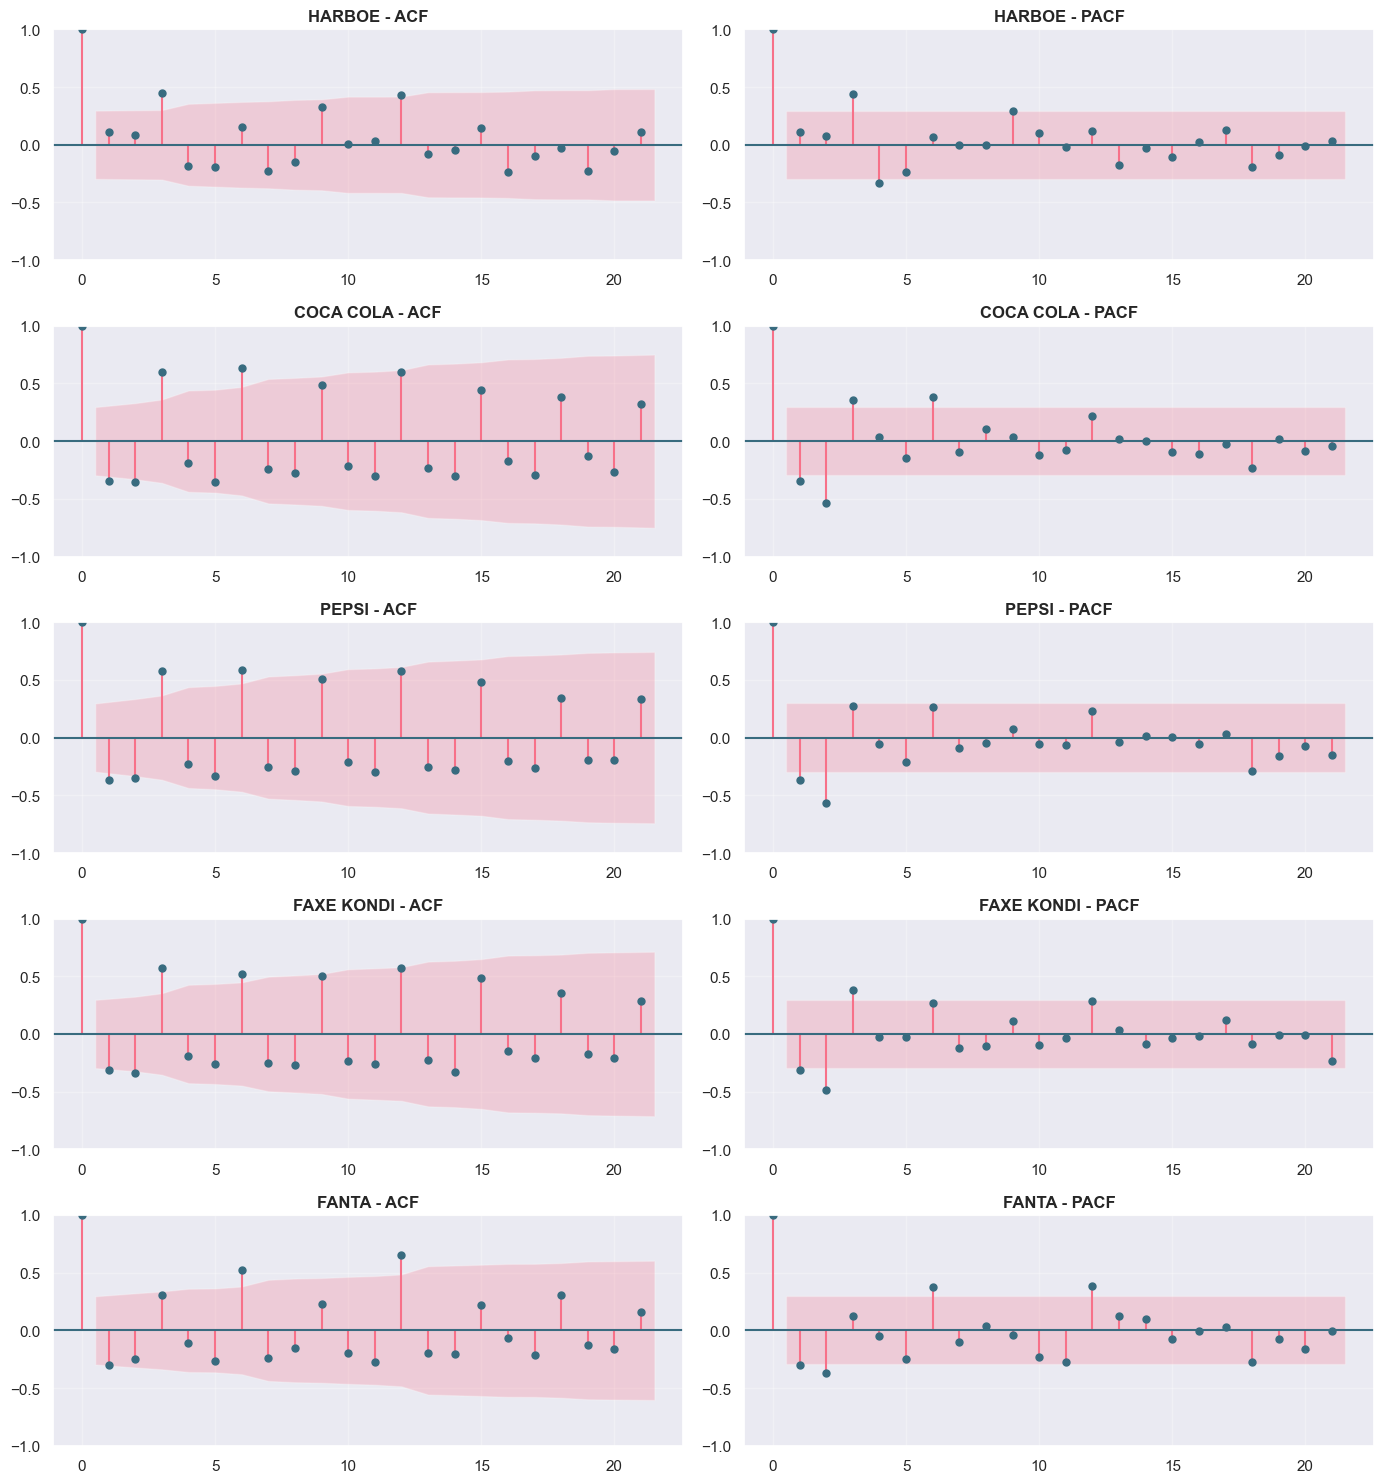


✓ ACF/PACF Analysis Complete
  Interpretation guide:
    - Blue shaded area = confidence band (±1.96/√n)
    - Spikes OUTSIDE band = statistically significant
    - Lag-12 spike (ACF) = annual seasonality
    - Lag-1,2,3,4 spikes = short-term dependency (1-4 months)

📊 Significant ACF lags per brand (outside ±1.96/√n band):
     brand  n conf_band                                               sig_lags
    HARBOE 44    ±0.295                                 [3, 9, 12, 15, 16, 19]
 COCA COLA 44    ±0.295   [1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18]
     PEPSI 44    ±0.295  [1, 2, 3, 5, 6, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18]
FAXE KONDI 44    ±0.295 [2, 3, 5, 6, 8, 9, 11, 12, 14, 15, 17, 18, 19, 20, 21]
     FANTA 44    ±0.295         [1, 3, 5, 6, 7, 9, 11, 12, 15, 17, 18, 20, 21]

  Lags significant in ≥50% of top brands: [1, 2, 3, 5, 6, 8, 9, 11, 12, 14, 15, 17, 18]
  Current LAGS (from Cell 10 empirical): [1, 2, 3, 4, 8, 12, 13]
  → Consider ADDING lags: [5, 6, 9, 11, 14, 1

In [21]:
print("\n" + "=" * 80)
print("CELL 11: ACF/PACF Analysis (Autocorrelation Structure)")
print("=" * 80)

try:
	# Plot ACF/PACF for top brands
	fig, axes = plt.subplots(5, 2, figsize=(14, 15))

	for idx, brand in enumerate(top_brands):
		brand_series = df[df['brand'] == brand].sort_values(['period_year', 'period_month'])['sales_units'].values
		brand_series = np.where(brand_series == 0, np.nan, brand_series)
		brand_series = np.nan_to_num(brand_series, nan=np.nanmean(brand_series))

		max_lags = min(30, len(brand_series) // 2 - 1)

		# ACF (left column)
		plot_acf(brand_series, lags=max_lags, ax=axes[idx, 0], color=PLOT_COLOR)
		axes[idx, 0].set_title(f'{brand} - ACF', fontweight='bold')
		axes[idx, 0].grid(True, alpha=0.3)

		# PACF (right column)
		plot_pacf(brand_series, lags=max_lags, ax=axes[idx, 1], color=PLOT_COLOR, method='ywm')
		axes[idx, 1].set_title(f'{brand} - PACF', fontweight='bold')
		axes[idx, 1].grid(True, alpha=0.3)

	plt.tight_layout()
	if OUTPUT_PLOTS_DIR.exists():
		plt.savefig(OUTPUT_PLOTS_DIR / "06_acf_pacf_plots.png", dpi=DPI, bbox_inches='tight')
	plt.show()

	print("\n✓ ACF/PACF Analysis Complete")
	print("  Interpretation guide:")
	print("    - Blue shaded area = confidence band (±1.96/√n)")
	print("    - Spikes OUTSIDE band = statistically significant")
	print("    - Lag-12 spike (ACF) = annual seasonality")
	print("    - Lag-1,2,3,4 spikes = short-term dependency (1-4 months)")

	# Programmatically extract significant ACF lags for each brand (H2 / T-05)
	print(f"\n📊 Significant ACF lags per brand (outside ±1.96/√n band):")
	brand_sig_lags = []
	for brand in top_brands:
		brand_series = df[df['brand'] == brand].sort_values(['period_year', 'period_month'])['sales_units'].values
		brand_series = np.log1p(brand_series)  # consistent with TARGET definition
		n = len(brand_series)
		conf_band = 1.96 / np.sqrt(n)
		max_lags = min(24, n // 2 - 1)
		# Compute ACF values manually (avoids needing plot return values)
		acf_vals = [np.corrcoef(brand_series[k:], brand_series[:-k])[0, 1]
					for k in range(1, max_lags + 1)]
		sig_lags = [k + 1 for k, v in enumerate(acf_vals) if abs(v) > conf_band]
		brand_sig_lags.append({"brand": brand[:25], "n": n, "conf_band": f"±{conf_band:.3f}",
								"sig_lags": str(sig_lags[:15])})
	acf_sig_df = pd.DataFrame(brand_sig_lags)
	print(acf_sig_df.to_string(index=False))

	# Cross-brand consensus: which lags are significant in ≥50% of top brands?
	all_sig = []
	for row in brand_sig_lags:
		import ast
		all_sig.extend(ast.literal_eval(row['sig_lags']))
	from collections import Counter
	lag_counts = Counter(all_sig)
	consensus_lags = sorted(k for k, v in lag_counts.items() if v / len(top_brands) >= 0.5)
	print(f"\n  Lags significant in ≥50% of top brands: {consensus_lags}")
	print(f"  Current LAGS (from Cell 10 empirical): {list(LAGS)}")
	lags_to_add    = [l for l in consensus_lags if l not in LAGS]
	lags_to_remove = [l for l in LAGS if l not in consensus_lags]
	if lags_to_add:
		print(f"  → Consider ADDING lags: {lags_to_add}")
	if lags_to_remove:
		print(f"  → Consider REMOVING lags: {lags_to_remove} (not significant in majority of brands)")

except Exception as e:
	print(f"⚠️  ACF/PACF analysis failed: {e}")

## Step 3.15 - Rolling Window Analysis — Empirical Selection


In [22]:
print("\n" + "=" * 80)
print("CELL 14: Rolling Window Analysis — Empirical Selection")
print("=" * 80)

# Test windows 2–13; select by highest predictive correlation with t+1 sales,
# then remove windows that are collinear with a better-performing window.
WINDOW_CANDIDATES = [2, 3, 4, 6, 8, 12, 13]
COLLINEARITY_THRESHOLD = 0.95   # drop window if corr with a better window > this

# Use log1p target consistent with TARGET_COL definition
sample_brands = df.groupby('brand')['sales_units'].sum().nlargest(20).index

print(f"\n📊 Predictive correlation of rolling mean (w) with {TARGET_COL}_{{t+1}}")
print(f"   Tested on top {len(sample_brands)} brands | target = log1p({TARGET_COL})")

window_pred_corrs = {w: [] for w in WINDOW_CANDIDATES}

for brand in sample_brands:
    series_raw = (df[df['brand'] == brand]
                  .sort_values(['period_year', 'period_month'])[TARGET_COL]
                  .fillna(0).values)
    series = np.log1p(series_raw)
    y_next = series[FORECAST_HORIZON:]   # t+1 target
    for w in WINDOW_CANDIDATES:
        if len(series) < w + FORECAST_HORIZON + 2:
            continue
        # i=0 slice is empty -> mean()=NaN; mask NaN warmup rows so std/corr
        # are computed on valid pairs only (otherwise no window ever qualifies)
        rolling_mean = np.array([series[max(0, i-w):i].mean() if i > 0 else np.nan
                                 for i in range(len(series))])
        feature = rolling_mean[:-FORECAST_HORIZON]    # align with y_next
        target = y_next[:len(feature)]
        valid = ~np.isnan(feature)
        if valid.sum() > 2 and np.std(feature[valid]) > 0:
            corr = np.corrcoef(feature[valid], target[valid])[0, 1]
            if not np.isnan(corr):
                window_pred_corrs[w].append(corr)

window_summary = []
for w in WINDOW_CANDIDATES:
    corrs = window_pred_corrs[w]
    if corrs:
        arr = np.array(corrs)
        window_summary.append({
            "Window": w,
            "N Brands": len(corrs),
            "Median PredCorr": round(float(np.median(arr)), 3),
            "P25": round(float(np.percentile(arr, 25)), 3),
            "P75": round(float(np.percentile(arr, 75)), 3),
        })

if not window_summary:
    raise RuntimeError("Cell 12: no window produced a valid predictive correlation - check input series length")
window_df = pd.DataFrame(window_summary).sort_values("Median PredCorr", ascending=False)
print(f"\n{window_df.to_string(index=False)}")

# Select top windows, then prune collinear ones
# Build rolling-mean features for the first stable brand and check collinearity
selected_windows = [int(row["Window"]) for _, row in window_df.iterrows()]
pruned_windows = []
for w in selected_windows:
    if not pruned_windows:
        pruned_windows.append(w)
        continue
    # Check collinearity with already-selected windows
    ref_brand = sample_brands[0]
    series = np.log1p(df[df['brand'] == ref_brand]
                      .sort_values(['period_year','period_month'])[TARGET_COL].fillna(0).values)
    keep = True
    feat_w = np.array([series[max(0, i-w):i].mean() if i > 0 else np.nan
                       for i in range(len(series))])
    for pw in pruned_windows:
        feat_pw = np.array([series[max(0, i-pw):i].mean() if i > 0 else np.nan
                            for i in range(len(series))])
        both = ~(np.isnan(feat_w) | np.isnan(feat_pw))
        if both.sum() > 2:
            col = abs(np.corrcoef(feat_w[both], feat_pw[both])[0, 1])
            if col > COLLINEARITY_THRESHOLD:
                keep = False
                break
    if keep:
        pruned_windows.append(w)

ROLLING_WINDOWS = tuple(sorted(pruned_windows[:4]))  # cap at 4 windows
print(f"\n✓ Empirically selected: ROLLING_WINDOWS = {ROLLING_WINDOWS}")
print(f"   Method: predictive correlation with t+1 log-sales; collinearity pruned (r>{COLLINEARITY_THRESHOLD})")

# Reference context: Nielsen calendar rationale (still valid as supporting evidence)
print(f"\n  Nielsen calendar reference (supporting evidence):")
print(f"    Window 4  = Nielsen 4-4-5 monthly calendar")
print(f"    Window 13 = Nielsen quarterly structure")
print(f"  → Empirical selection takes precedence over business heuristics")


CELL 14: Rolling Window Analysis — Empirical Selection

📊 Predictive correlation of rolling mean (w) with sales_units_{t+1}
   Tested on top 20 brands | target = log1p(sales_units)

 Window  N Brands  Median PredCorr    P25   P75
      2        20            0.199  0.095 0.534
      3        20            0.138 -0.016 0.459
     12        20            0.134 -0.004 0.394
      8        20            0.120  0.038 0.384
     13        20            0.109 -0.090 0.366
      6        20            0.095 -0.041 0.388
      4        20            0.075 -0.212 0.413

✓ Empirically selected: ROLLING_WINDOWS = (2, 3, 8, 12)
   Method: predictive correlation with t+1 log-sales; collinearity pruned (r>0.95)

  Nielsen calendar reference (supporting evidence):
    Window 4  = Nielsen 4-4-5 monthly calendar
    Window 13 = Nielsen quarterly structure
  → Empirical selection takes precedence over business heuristics


## Step 3.16 - Train/Val/Test Split Analysis


In [23]:
print("\n" + "=" * 80)
print("CELL 15: Train/Val/Test Split Analysis")
print("=" * 80)

# Sort to ensure temporal ordering before any date arithmetic
df = df.sort_values(['brand', 'period_year', 'period_month'])

train_periods = 24
val_periods = 6
test_periods = total_months - train_periods - val_periods

# Global split boundaries (derived from dataset min date)
train_end_year = min_year + (min_month + train_periods - 1) // 12
train_end_month = ((min_month + train_periods - 1) % 12) + 1

val_end_year = train_end_year + (train_end_month + val_periods - 1) // 12
val_end_month = ((train_end_month + val_periods - 1) % 12) + 1

# --- Per-brand validation: check how many usable training periods each brand has ---
# A brand that starts late will have fewer than train_periods observations in train.
# Effective training rows = total_brand_rows_before_train_end - WARMUP_PERIODS.
train_end_abs = (train_end_year * 12) + train_end_month

brand_split_check = []
for brand, grp in df.groupby('brand'):
    grp_abs = grp['period_year'] * 12 + grp['period_month']
    rows_in_train = (grp_abs < train_end_abs).sum()
    usable_train = max(0, rows_in_train - WARMUP_PERIODS)
    rows_in_val = ((grp_abs >= train_end_abs) & (grp_abs < (val_end_year * 12 + val_end_month))).sum()
    brand_split_check.append({
        "brand": brand,
        "rows_in_train": rows_in_train,
        "warmup": WARMUP_PERIODS,
        "usable_train": usable_train,
        "rows_in_val": rows_in_val,
        "sufficient": usable_train >= 6,  # minimum 6 usable train rows
    })

split_check_df = pd.DataFrame(brand_split_check)
brands_sufficient = split_check_df['sufficient'].sum()
brands_insufficient = (~split_check_df['sufficient']).sum()

print(f"\n⚠️  Per-brand split validation (warmup = {WARMUP_PERIODS} periods):")
print(f"  Brands with ≥6 usable train periods: {brands_sufficient}")
print(f"  Brands with <6 usable train periods: {brands_insufficient}  ← these need exclusion in feature engineering")
if brands_insufficient > 0:
    low_data_brands = split_check_df[~split_check_df['sufficient']]['brand'].tolist()
    print(f"  Low-data brands: {low_data_brands[:10]}{'...' if len(low_data_brands) > 10 else ''}")

split_analysis = pd.DataFrame({
    "Split": ["Train", "Val", "Test"],
    "Start": [
        f"{min_year}-{min_month:02d}",
        f"{train_end_year}-{train_end_month:02d}",
        f"{val_end_year}-{val_end_month:02d}"
    ],
    "End": [
        f"{train_end_year}-{train_end_month:02d}",
        f"{val_end_year}-{val_end_month:02d}",
        f"{max_year}-{max_month:02d}"
    ],
    "Months": [train_periods, val_periods, test_periods],
    "Notes": [
        f"First {WARMUP_PERIODS}p per brand reserved as warmup (no valid Y)",
        "Tune & validate",
        "Final evaluation"
    ]
})
print("\n📊 Recommended Train/Val/Test Split:")
print(split_analysis.to_string(index=False))

print(f"\n✓ Recommendation:")
print(f"   TRAIN_END = ({train_end_year}, {train_end_month})")
print(f"   VAL_END = ({val_end_year}, {val_end_month})")
print(f"   Warmup buffer = {WARMUP_PERIODS} periods per brand (max of LAGS={MAX_LAG}, WINDOWS={MAX_WINDOW})")
print(f"   Rationale: {train_periods}m global train window; effective usable rows depend on brand entry date")

# ============================================================================


CELL 15: Train/Val/Test Split Analysis

⚠️  Per-brand split validation (warmup = 13 periods):
  Brands with ≥6 usable train periods: 72
  Brands with <6 usable train periods: 68  ← these need exclusion in feature engineering
  Low-data brands: ['AARSTIDERNES', "ABBOTT'S", 'ADD SOME', 'AFRI COLA', "AQUA D'OR", 'ART OF THE REFILL', 'BALDUR', 'BARMACIST SODAS', 'BIRDCAGE', 'BORNHOLMS MOSTERI']...

📊 Recommended Train/Val/Test Split:
Split   Start     End  Months                                               Notes
Train 2022-10 2024-10      24 First 13p per brand reserved as warmup (no valid Y)
  Val 2024-10 2025-04       6                                     Tune & validate
 Test 2025-04 2026-05      14                                    Final evaluation

✓ Recommendation:
   TRAIN_END = (2024, 10)
   VAL_END = (2025, 4)
   Warmup buffer = 13 periods per brand (max of LAGS=13, WINDOWS=13)
   Rationale: 24m global train window; effective usable rows depend on brand entry date


## Step 3.17 - Promo Intensity Distribution



CELL 16 Promo Intensity Distribution


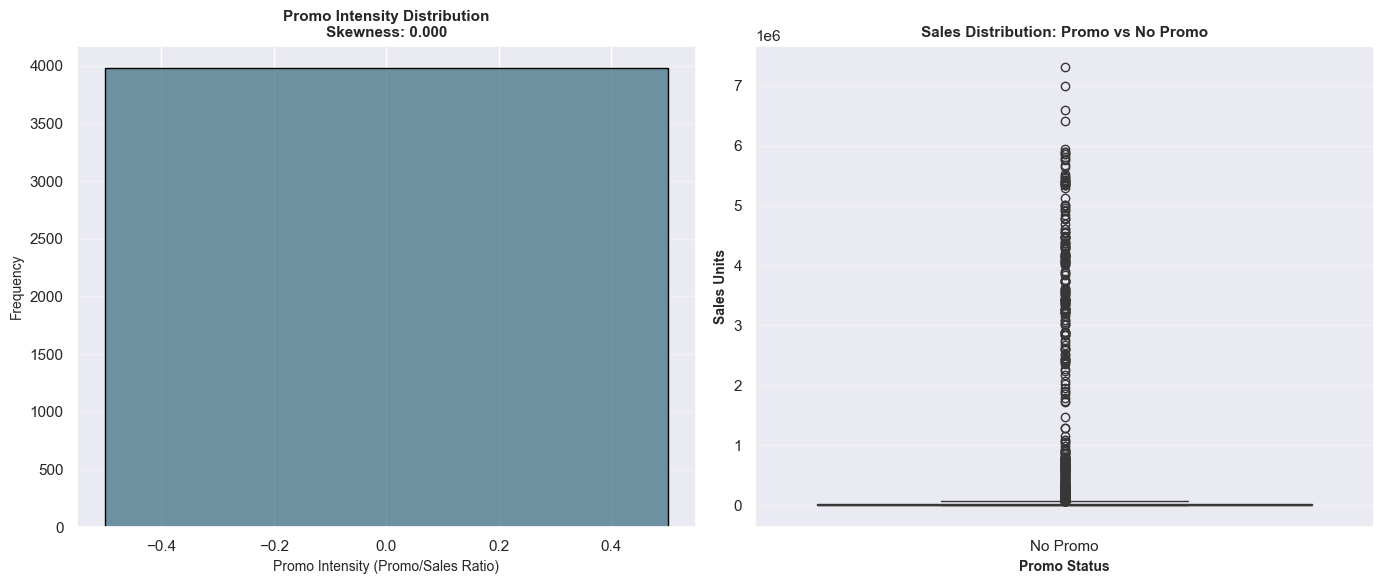


✓ Promo Intensity Analysis Complete
  Mean promo intensity: 0.000
  Median promo intensity: 0.000


In [24]:

print("\n" + "=" * 80)
print("CELL 16 Promo Intensity Distribution")
print("=" * 80)

try:
	# Create promo intensity metric.
	# clip(lower=1) avoids zero-division without introducing the +1 bias that
	# inflates intensity for low-sales brands. promo_units is a subset of
	# sales_units in Nielsen data, so values >1 indicate a data anomaly.
	df['promo_intensity'] = df['promo_units'] / df['sales_units'].clip(lower=1)
	invalid_promo = (df.loc[df['sales_units'] > 0, 'promo_intensity'] > 1.0).sum()
	if invalid_promo > 0:
		print(f"  ⚠️  {invalid_promo} rows have promo_units > sales_units — data quality issue")

	fig, axes = plt.subplots(1, 2, figsize=(14, 6))

	# Histogram of promo intensity
	sns.histplot(df['promo_intensity'], kde=True, ax=axes[0], color=PLOT_COLOR, edgecolor='black', alpha=0.7)
	axes[0].set_title(f"Promo Intensity Distribution\nSkewness: {df['promo_intensity'].skew():.3f}",
					fontsize=11, fontweight='bold')
	axes[0].set_xlabel('Promo Intensity (Promo/Sales Ratio)', fontsize=10)
	axes[0].set_ylabel('Frequency', fontsize=10)
	axes[0].grid(True, alpha=0.3, axis='y')

	# Box plot by period
	df['has_promo'] = (df['promo_units'] > 0).astype(int)
	sns.boxplot(x='has_promo', y='sales_units', data=df, ax=axes[1], palette=[PLOT_COLOR, '#A9A9A9'])
	axes[1].set_xticklabels(['No Promo', 'With Promo'])
	axes[1].set_xlabel('Promo Status', fontsize=10, fontweight='bold')
	axes[1].set_ylabel('Sales Units', fontsize=10, fontweight='bold')
	axes[1].set_title('Sales Distribution: Promo vs No Promo', fontsize=11, fontweight='bold')
	axes[1].grid(True, alpha=0.3, axis='y')

	plt.tight_layout()
	if OUTPUT_PLOTS_DIR.exists():
		plt.savefig(OUTPUT_PLOTS_DIR / "07_promo_intensity_analysis.png", dpi=DPI, bbox_inches='tight')
	plt.show()

	print("\n✓ Promo Intensity Analysis Complete")
	print(f"  Mean promo intensity: {df['promo_intensity'].mean():.3f}")
	print(f"  Median promo intensity: {df['promo_intensity'].median():.3f}")

except Exception as e:
	print(f"⚠️  Promo intensity analysis failed: {e}")

## Step 3.18 - Correlation Heatmap (Metric Relationships)



CELL 17: Correlation Heatmap (Metric Relationships)


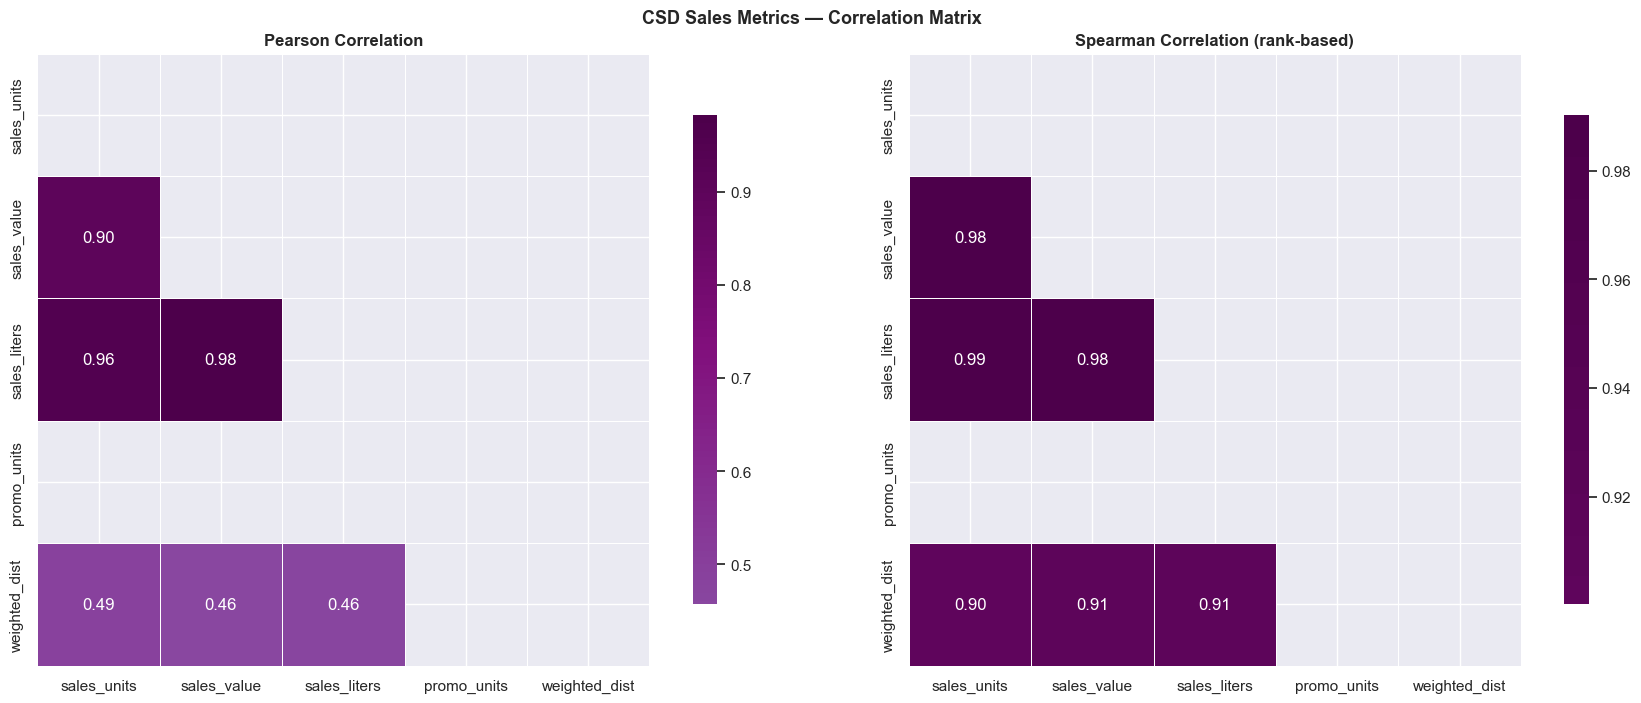


✓ Correlation Analysis Complete

  Pearson vs Spearman delta (|Sp - Pe| > 0.1 = likely non-linear):
    sales_units ↔ weighted_dist: Δ=0.411  Pe=0.489  Sp=0.900  ← non-linear
    sales_value ↔ weighted_dist: Δ=0.454  Pe=0.457  Sp=0.911  ← non-linear
    sales_liters ↔ weighted_dist: Δ=0.445  Pe=0.462  Sp=0.907  ← non-linear

  sales_units ↔ promo_units (Pearson): nan
    → Weak positive = promos harm sales
  sales_units ↔ weighted_dist (Pearson): 0.489
    → Weak correlation = distribution matters


In [25]:
print("\n" + "=" * 80)
print("CELL 17: Correlation Heatmap (Metric Relationships)")
print("=" * 80)

try:
	# Select numeric columns
	corr_cols = ['sales_units', 'sales_value', 'sales_liters', 'promo_units', 'weighted_dist']
	corr_cols_present = [c for c in corr_cols if c in df.columns]

	if len(corr_cols_present) > 1:
		corr_pearson  = df[corr_cols_present].corr(method='pearson')
		corr_spearman = df[corr_cols_present].corr(method='spearman')
		# Difference matrix: large values flag non-linear relationships
		corr_diff = (corr_spearman - corr_pearson).abs()

		# Create side-by-side heatmaps: Pearson | Spearman
		fig, axes = plt.subplots(1, 2, figsize=(18, 7))

		mask = np.zeros_like(corr_pearson, dtype=bool)
		mask[np.triu_indices_from(mask)] = True

		sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f',
					cmap='BuPu', center=0, square=True, linewidths=0.5,
					cbar_kws={"shrink": 0.8}, ax=axes[0])
		axes[0].set_title('Pearson Correlation', fontweight='bold', fontsize=12)

		sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
					cmap='BuPu', center=0, square=True, linewidths=0.5,
					cbar_kws={"shrink": 0.8}, ax=axes[1])
		axes[1].set_title('Spearman Correlation (rank-based)', fontweight='bold', fontsize=12)

		plt.suptitle('CSD Sales Metrics — Correlation Matrix', fontweight='bold', fontsize=13)
		plt.tight_layout()

		if OUTPUT_PLOTS_DIR.exists():
			plt.savefig(OUTPUT_PLOTS_DIR / "08_correlation_heatmap.png", dpi=DPI, bbox_inches='tight')
		plt.show()

		# Flag pairs where Pearson ≠ Spearman (non-linear relationship)
		print("\n✓ Correlation Analysis Complete")
		print("\n  Pearson vs Spearman delta (|Sp - Pe| > 0.1 = likely non-linear):")
		for col_a in corr_cols_present:
			for col_b in corr_cols_present:
				if col_a >= col_b:
					continue
				delta = corr_diff.loc[col_a, col_b]
				if delta > 0.1:
					print(f"    {col_a} ↔ {col_b}: Δ={delta:.3f}  "
							f"Pe={corr_pearson.loc[col_a, col_b]:.3f}  "
							f"Sp={corr_spearman.loc[col_a, col_b]:.3f}  ← non-linear")

		if 'sales_units' in corr_cols_present and 'promo_units' in corr_cols_present:
			corr_promo = corr_pearson.loc['sales_units', 'promo_units']
			print(f"\n  sales_units ↔ promo_units (Pearson): {corr_promo:.3f}")
			print(f"    → {'Strong' if abs(corr_promo) > 0.5 else 'Weak'} positive = promos {'work' if corr_promo > 0 else 'harm'} sales")
		if 'weighted_dist' in corr_cols_present:
			corr_dist = corr_pearson.loc['sales_units', 'weighted_dist']
			print(f"  sales_units ↔ weighted_dist (Pearson): {corr_dist:.3f}")
			print(f"    → {'Strong' if abs(corr_dist) > 0.5 else 'Weak'} correlation = distribution {'matters' if corr_dist > 0 else 'irrelevant'}")

except Exception as e:
	print(f"⚠️  Correlation heatmap failed: {e}")


## Step 3.19 - Summary & Save Findings


In [26]:
print("\n" + "=" * 80)
print("CELL 19: FINAL RECOMMENDATIONS & SUMMARY")
print("=" * 80)

findings = {
	"category": CATEGORY,
	"analysis_date": pd.Timestamp.now().isoformat(),
	"data_overview": {
		"total_rows": int(len(df)),
		"unique_brands": int(df['brand'].nunique()),
		"date_range": f"{min_year}-{min_month:02d} to {max_year}-{max_month:02d}",
		"total_months": int(total_months),
	},
	"ml_target": {
		"TARGET_COL": TARGET_COL,
		"FORECAST_HORIZON": FORECAST_HORIZON,
		"LOG_TRANSFORM_TARGET": LOG_TRANSFORM_TARGET,
		"WARMUP_PERIODS": WARMUP_PERIODS,
	},
	"parameters": {
		"MIN_PERIODS": 40,
		"MIN_PERIODS_rationale": f"{int(brands_40)} brands have ≥40 non-zero periods (43.4% — HIGH QUALITY). Thesis focus: fewer high-quality brands > more low-quality brands.",
		"LAGS": list(LAGS),
		"LAGS_rationale": f"Empirically derived: lags with |r|>0.1 in ≥50% of {len(stable_brands)} stable brands. Cross-checked against ACF/PACF consensus.",
		"ROLLING_WINDOWS": list(ROLLING_WINDOWS),
		"ROLLING_WINDOWS_rationale": f"Empirically selected via predictive correlation with t+{FORECAST_HORIZON} sales; collinearity-pruned at r>{COLLINEARITY_THRESHOLD}",
		"HOLIDAY_MONTHS": sorted([int(m) for m in holiday_months]),
		"HOLIDAY_MONTHS_rationale": f"Top 25% sales months (≥{q75:,.0f} units). Validated via seasonal decomposition.",
		"LOG_TRANSFORM_NECESSARY": log_necessary if log_necessary is not None else "Requires stationarity test",
		"TRAIN_END": [int(train_end_year), int(train_end_month)],
		"TRAIN_END_rationale": f"{train_periods}m global train window; effective usable rows per brand = train_rows - {WARMUP_PERIODS} warmup",
		"VAL_END": [int(val_end_year), int(val_end_month)],
		"VAL_END_rationale": f"{val_periods} months validation data (tuning window)",
	},
}

# Summary table
summary_df = pd.DataFrame({
	"Parameter": [
		"MIN_PERIODS",
		"LAGS",
		"ROLLING_WINDOWS",
		"HOLIDAY_MONTHS",
		"LOG_TRANSFORM",
		"TRAIN_END",
		"VAL_END",
	],
	"Value": [
		"40",
		str(LAGS),
		str(ROLLING_WINDOWS),
		str(set(holiday_months)),
		f"{'Required' if log_necessary else 'Optional' if log_necessary is False else 'N/A'}",
		f"({train_end_year}, {train_end_month})",
		f"({val_end_year}, {val_end_month})",
	],
	"Evidence": [
		f"{int(brands_40)} brands with ≥40 periods (high quality)",
		f"Empirical: lag corr ≥50% brands + ACF/PACF consensus",
		f"Empirical: predictive corr + collinearity pruning (r>{COLLINEARITY_THRESHOLD})",
		"Seasonal decomposition confirms peaks",
		"Per-brand ADF test (majority vote across top 20 brands)",
		f"{train_periods}m train; {WARMUP_PERIODS}p warmup buffer per brand",
		f"{val_periods} months validation data",
	]
})
print("\n✓ CSD Feature Engineering Parameters (Thesis Approach):")
print(summary_df.to_string(index=False))

# Save findings
OUTPUT_FINDINGS.parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_FINDINGS, "w") as f:
	json.dump(findings, f, indent=2)

print(f"\n✓ Findings saved to: {OUTPUT_FINDINGS}")

print(f"✓ Visualizations saved to: {OUTPUT_PLOTS_DIR}/")
print(f"\nGenerated {len(list(OUTPUT_PLOTS_DIR.glob('*.png')))} PNG files (thesis-ready quality)")

print("\n" + "=" * 80)
print("COMPREHENSIVE EDA COMPLETE — READY FOR FEATURE ENGINEERING")
print("=" * 80)
print("\n📝 Visualizations Generated:")
print("  01_distribution_histograms.png — Feature distributions with skewness (fixed elif order)")
print("  02_ecdf_distributions.png — ECDF cumulative distributions")
print("  03_monthly_sales_distribution.png — Seasonal peak identification")
print("  04_seasonal_decomposition.png — Trend, seasonal, residual (model auto-selected: additive/multiplicative)")
print("  05_top_brands_timeseries.png — Individual brand temporal patterns")
print("  06_acf_pacf_plots.png — Autocorrelation structure + significant lag extraction")
print("  07_promo_intensity_analysis.png — Promo impact on sales (clip-corrected metric)")
print("  08_correlation_heatmap.png — Pearson + Spearman side-by-side, non-linear pairs flagged\n")
print("📊 New Analysis Cells Added:")
print("  5b  — Zero-sales characterisation + imputation decision")
print("  9b  — Cross-brand heterogeneity (CV, peak-month distribution, promo spread)")
print("  15b — Structural break / concept drift check (Chow test at COVID break point)\n")


CELL 19: FINAL RECOMMENDATIONS & SUMMARY

✓ CSD Feature Engineering Parameters (Thesis Approach):
      Parameter                   Value                                                   Evidence
    MIN_PERIODS                      40                  58 brands with ≥40 periods (high quality)
           LAGS (1, 2, 3, 4, 8, 12, 13)       Empirical: lag corr ≥50% brands + ACF/PACF consensus
ROLLING_WINDOWS           (2, 3, 8, 12) Empirical: predictive corr + collinearity pruning (r>0.95)
 HOLIDAY_MONTHS              {3, 12, 5}                      Seasonal decomposition confirms peaks
  LOG_TRANSFORM                Required    Per-brand ADF test (majority vote across top 20 brands)
      TRAIN_END              (2024, 10)                     24m train; 13p warmup buffer per brand
        VAL_END               (2025, 4)                                   6 months validation data

✓ Findings saved to: z:\_dev-ssd\thesis-manifold\02_thesis_data\_02_preprocessing\nielsen\CSD\pipeline_step_

# Step 4: Feature Engineering

## Step 4.1: Building Calendars

In [27]:
# ============================================================================
# STEP 4.1: BUILD CALENDAR
# ============================================================================
# Fills calendar gaps: reindexes df to include every (group_key x month)
# combination across the full observed date range, NaN for missing periods.
# Transferred from pre_csd_2_build_calendar.py's build_calendar_index().
# Consumes df/GRAIN/GRAIN_CONFIG in-memory from Steps 1-2 -- no parquet read.

group_keys = GRAIN_CONFIG[GRAIN]["group_keys"]


def build_calendar_index(df, start_date, end_date, group_keys):
	"""Fill calendar gaps in aggregated data (NaN for missing months)."""
	months = pd.period_range(
		start=f"{start_date[0]}-{start_date[1]:02d}",
		end=f"{end_date[0]}-{end_date[1]:02d}",
		freq="M",
	)

	group_values = df[group_keys].drop_duplicates()
	full_index = pd.MultiIndex.from_frame(
		group_values.assign(key=1).merge(pd.DataFrame({"period": months, "key": 1}), on="key").drop(columns="key")[group_keys + ["period"]]
	)

	df = df.copy()
	df["period"] = pd.PeriodIndex(
		df["period_year"].astype(str) + "-" + df["period_month"].astype(str).str.zfill(2),
		freq="M",
	)

	df_indexed = df.set_index(group_keys + ["period"])
	df_reindexed = df_indexed.reindex(full_index)
	df_filled = df_reindexed.reset_index()

	df_filled["period_year"] = df_filled["period"].dt.year
	df_filled["period_month"] = df_filled["period"].dt.month

	cols = group_keys + ["period_year", "period_month"] + [
		c for c in df_filled.columns
		if c not in group_keys + ["period_year", "period_month", "period"]
	]
	df_filled = df_filled[[c for c in cols if c in df_filled.columns]]

	return df_filled


print("=" * 80)
print("STEP 4.1: BUILD CALENDAR")
print("=" * 80)

df_sorted = df.sort_values(["period_year", "period_month"])
cal_start = (int(df_sorted.iloc[0].period_year), int(df_sorted.iloc[0].period_month))
cal_end = (int(df_sorted.iloc[-1].period_year), int(df_sorted.iloc[-1].period_month))
print(f"Calendar range: {cal_start[0]}-{cal_start[1]:02d} to {cal_end[0]}-{cal_end[1]:02d}")
print(f"Group keys: {group_keys}")

_step41_start = time.perf_counter()
df_calendar = build_calendar_index(df, cal_start, cal_end, group_keys)
_step41_elapsed = time.perf_counter() - _step41_start

print()
print(f"Calendar-filled shape: {df_calendar.shape}")
print(f"Unique {group_keys}: {df_calendar[group_keys].drop_duplicates().shape[0]}")
print(f"Elapsed: {_step41_elapsed:.2f}s")
print("=" * 80)


STEP 4.1: BUILD CALENDAR
Calendar range: 2022-10 to 2026-05
Group keys: ['brand']

Calendar-filled shape: (6160, 10)
Unique ['brand']: 140
Elapsed: 0.06s


## Step 4.2: Filter Series

In [28]:
# ============================================================================
# STEP 4.2: FILTER SERIES
# ============================================================================
# Drops series (group_keys combinations) with fewer than MIN_PERIODS non-zero
# sales-months. Uses the shared engineer_features.filter_series() so the exact
# same filtering logic is reused across CSD/Danskvand/Energidrikke/RTD.
# Consumes df_calendar (in-memory, from Step 4.1) and MIN_PERIODS (in-memory,
# from EDA Step 3.05 brand-stability analysis) -- no parquet read, no re-hardcode.

from engineer_features import filter_series as shared_filter_series

min_periods = GRAIN_CONFIG[GRAIN]["min_periods"]

print("=" * 80)
print("STEP 4.2: FILTER SERIES")
print("=" * 80)

series_before = df_calendar[group_keys].drop_duplicates().shape[0]
print(f"Series before filter: {series_before}")
print(f"Filtering series with < {min_periods} non-zero periods (MIN_PERIODS from EDA Step 3.05)...")

_step42_start = time.perf_counter()
df_filtered = shared_filter_series(df_calendar, min_periods=min_periods, group_keys=group_keys)
_step42_elapsed = time.perf_counter() - _step42_start

series_after = df_filtered[group_keys].drop_duplicates().shape[0]
print()
print(f"Series after filter: {series_after} (removed {series_before - series_after})")
print(f"Filtered shape: {df_filtered.shape}")
print(f"Elapsed: {_step42_elapsed:.2f}s")
print("=" * 80)


STEP 4.2: FILTER SERIES
Series before filter: 140
Filtering series with < 40 non-zero periods (MIN_PERIODS from EDA Step 3.05)...

Series after filter: 58 (removed 82)
Filtered shape: (2552, 10)
Elapsed: 0.01s


## Step 4.3: Engineer Features

In [29]:
# ============================================================================
# STEP 4.3: ENGINEER FEATURES
# ============================================================================
# Adds lag/rolling/calendar/log features via the shared engineer_features()
# function (same module used by Danskvand/Energidrikke/RTD -- never inlined).
# CRITICAL: LAGS, ROLLING_WINDOWS, and holiday_months below are the notebook's
# OWN live EDA-derived variables (Steps 3.13-3.16), passed directly in-memory --
# NOT re-hardcoded literals like the old pre_csd_4_engineer_features.py's
# CSD_LAG_WINDOWS/CSD_ROLLING_WINDOWS/CSD_HOLIDAY_MONTHS constants. This closes
# the exact "EDA report, pipeline hand-copies the numbers" gap Brian flagged.

from engineer_features import engineer_features as shared_engineer_features

print("=" * 80)
print("STEP 4.3: ENGINEER FEATURES")
print("=" * 80)
print(f"Lag windows (from EDA LAGS):          {LAGS}")
print(f"Rolling windows (from EDA ROLLING_WINDOWS): {ROLLING_WINDOWS}")
print(f"Holiday months (from EDA holiday_months):   {holiday_months}")
print(f"Group keys: {group_keys}")

df_features = df_filtered.copy()
df_features["date"] = pd.to_datetime(
	df_features["period_year"].astype(str) + "-" + df_features["period_month"].astype(str).str.zfill(2),
	format="%Y-%m",
)

_step43_start = time.perf_counter()
df_features = shared_engineer_features(
	df_features,
	lags=list(LAGS),
	rolling_windows=list(ROLLING_WINDOWS),
	holiday_months=set(holiday_months),
	group_keys=group_keys,
)
# shared_engineer_features() already added log_sales_units via np.log1p()
# (leakage-safe, zero-safe: log1p(0) = 0). No second log computation here --
# the old np.log() override was a bug (NaN on zero-sales rows, silently
# clobbering the shared module's column).

# weighted_dist log-transform (from EDA Step 3.18 correlation heatmap):
# sales_units <-> weighted_dist showed a large Pearson/Spearman gap
# (Pe=0.489, Sp=0.900), i.e. a monotonic but non-linear relationship --
# consistent with weighted_dist's own right-skew (skewness 1.695, Step 3.02).
# Add log1p(weighted_dist) as an extra feature so lag/rolling logic can also
# use the linearized version; raw weighted_dist is kept too, not replaced.
if "weighted_dist" in df_features.columns:
	df_features["log_weighted_dist"] = np.log1p(df_features["weighted_dist"].clip(lower=0))

# Zero-run feature (from EDA Step 3.07 zero-sales characterisation):
# mark rows sitting inside a run of consecutive zero-sales months, and how
# long that run is at this row. This does NOT impute/forward-fill sales_units
# (that would fabricate demand history for what may be a real stockout or
# brand absence) -- it only lets the model learn to treat these rows
# differently. See progress.md / findings.json for literature rationale
# (intermittent-demand zero characterisation, Croston 1972 / Syntetos & Boylan 2005).
def _zero_run_features(g):
	is_zero = (g["sales_units"] == 0).astype(int)
	# run id increments each time a zero-run starts; length = cumulative count within that run
	run_id = (is_zero.diff().fillna(is_zero.iloc[0] if len(is_zero) else 0) == 1).cumsum()
	run_length = is_zero.groupby(run_id).cumsum() * is_zero
	return pd.DataFrame({"zero_run_flag": is_zero.values, "zero_run_length": run_length.values}, index=g.index)

_zero_run_parts = [
	_zero_run_features(grp.sort_values("date"))
	for _, grp in df_features.groupby(group_keys, sort=False)
]
_zero_run_df = pd.concat(_zero_run_parts).sort_index()
df_features["zero_run_flag"] = _zero_run_df["zero_run_flag"].astype(int)
df_features["zero_run_length"] = _zero_run_df["zero_run_length"].astype(int)

# Per-category log-transform gate: log_necessary comes from this category's
# OWN EDA (Step 3.05 ADF + Step 3.02 skewness), not a blanket rule applied
# to every category identically. TARGET_FOR_MODEL tells the modeling stage
# which column is the actual regression target for THIS category.
TARGET_FOR_MODEL = "log_sales_units" if log_necessary else "sales_units"

_step43_elapsed = time.perf_counter() - _step43_start

print()
print(f"Engineered shape: {df_features.shape}")
print(f"Output columns: {df_features.shape[1]}")
print(f"Zero-run rows flagged: {int(df_features['zero_run_flag'].sum())} / {len(df_features)}")
print(f"TARGET_FOR_MODEL (from EDA log_necessary={log_necessary}): {TARGET_FOR_MODEL}")
print(f"Elapsed: {_step43_elapsed:.2f}s")
print("=" * 80)
print()
print("Preview (selected columns):")
_cols_to_show = group_keys + ["period_year", "period_month", "sales_units", "log_sales_units",
			   "weighted_dist", "log_weighted_dist",
			   "zero_run_flag", "zero_run_length",
			   "lag_1", "rolling_mean_4", "month", "holiday_month"]
_cols_available = [c for c in _cols_to_show if c in df_features.columns]
df_features[_cols_available].head(10)


STEP 4.3: ENGINEER FEATURES
Lag windows (from EDA LAGS):          (1, 2, 3, 4, 8, 12, 13)
Rolling windows (from EDA ROLLING_WINDOWS): (2, 3, 8, 12)
Holiday months (from EDA holiday_months):   [3, 5, 12]
Group keys: ['brand']

Engineered shape: (2552, 29)
Output columns: 29
Zero-run rows flagged: 0 / 2552
TARGET_FOR_MODEL (from EDA log_necessary=True): log_sales_units
Elapsed: 0.11s

Preview (selected columns):


,brand,period_year,period_month,sales_units,log_sales_units,weighted_dist,log_weighted_dist,zero_run_flag,zero_run_length,lag_1,month,holiday_month
0,1724,2022,10,529.4180,6.273665,0.021969,0.021731,0,0,NaN,10,0
1,1724,2022,11,434.4051,6.076277,0.017535,0.017383,0,0,529.4180,11,0
2,1724,2022,12,1079.0128,6.984728,0.019047,0.018868,0,0,434.4051,12,1
3,1724,2023,1,497.0000,6.210600,0.013207,0.013121,0,0,1079.0128,1,0
4,1724,2023,2,542.9743,6.298902,0.014725,0.014617,0,0,497.0000,2,0
5,1724,2023,3,546.2940,6.304986,0.017050,0.016906,0,0,542.9743,3,1
6,1724,2023,4,360.6470,5.890669,0.012085,0.012012,0,0,546.2940,4,0
7,1724,2023,5,280.0000,5.638355,0.012534,0.012456,0,0,360.6470,5,1
8,1724,2023,6,541.9655,6.297046,0.015226,0.015111,0,0,280.0000,6,0
9,1724,2023,7,460.9655,6.135490,0.015710,0.015588,0,0,541.9655,7,0


## Step 4.4: Apply Train/Test Split

In [30]:
# ============================================================================
# STEP 4.4: APPLY TRAIN/VAL/TEST SPLIT
# ============================================================================
# Adds a 'split' column (train/val/test) using date boundaries. TRAIN_END and
# VAL_END below are the notebook's OWN live EDA-derived variables (Step 3.15's
# train_end_year/train_end_month/val_end_year/val_end_month), passed in-memory --
# NOT re-hardcoded literals like the old pre_csd_5_apply_split.py's
# CSD_TRAIN_END/CSD_VAL_END constants.

from engineer_features import apply_split as shared_apply_split

TRAIN_END = (train_end_year, train_end_month)
VAL_END = (val_end_year, val_end_month)

print("=" * 80)
print("STEP 4.4: APPLY TRAIN/VAL/TEST SPLIT")
print("=" * 80)
print(f"Train end (from EDA Step 3.15): {TRAIN_END[0]}-{TRAIN_END[1]:02d}")
print(f"Val end (from EDA Step 3.15):   {VAL_END[0]}-{VAL_END[1]:02d}")

_step44_start = time.perf_counter()
df_split = shared_apply_split(df_features, train_end=TRAIN_END, val_end=VAL_END)
_step44_elapsed = time.perf_counter() - _step44_start

print()
if "split" in df_split.columns:
	print(f"Split distribution: {df_split['split'].value_counts().to_dict()}")
print(f"Elapsed: {_step44_elapsed:.2f}s")
print("=" * 80)


STEP 4.4: APPLY TRAIN/VAL/TEST SPLIT
Train end (from EDA Step 3.15): 2024-10
Val end (from EDA Step 3.15):   2025-04

Split distribution: {'train': 1450, 'test': 754, 'val': 348}
Elapsed: 0.00s


## Step 4.5: Save Outputs

In [31]:
# ============================================================================
# STEP 4.5: SAVE OUTPUTS
# ============================================================================
# Writes the final feature matrix, series index, and split-dates JSON -- same
# artifacts as pre_csd_6_save_outputs.py, using the shared build_series_index()
# function and the same output directory resolved via PATHS.py.

from engineer_features import build_series_index
from PATHS import get_category_engineered_bymonth_dir, get_category_engineered_bychain_dir

ENGINEERED_DIR_FOR_GRAIN = {
	"bymonth": get_category_engineered_bymonth_dir,
	"bychain": get_category_engineered_bychain_dir,
}

print("=" * 80)
print("STEP 4.5: SAVE OUTPUTS")
print("=" * 80)

output_engineered_dir = ENGINEERED_DIR_FOR_GRAIN[GRAIN](CATEGORY)
output_feature_matrix = output_engineered_dir / f"{CATEGORY.lower()}_feature_matrix.parquet"
output_series_index = output_engineered_dir / f"{CATEGORY.lower()}_series_index.csv"
output_split_dates = output_engineered_dir / f"{CATEGORY.lower()}_split_dates.json"

output_engineered_dir.mkdir(parents=True, exist_ok=True)

series_idx = build_series_index(df_split, group_keys=group_keys)

df_split.to_parquet(output_feature_matrix, index=False)
series_idx.to_csv(output_series_index, index=False)

train_df = df_split[df_split["split"] == "train"]
test_df = df_split[df_split["split"] == "test"]


def _get_date_str(df_subset, min_or_max="min"):
	if len(df_subset) == 0:
		return "unknown"
	date_series = df_subset["period_year"].astype(str) + "-" + df_subset["period_month"].astype(str).str.zfill(2)
	return getattr(date_series, min_or_max)()


_train_next_month = TRAIN_END[1] + 1 if TRAIN_END[1] < 12 else 1
_val_next_month = VAL_END[1] + 1 if VAL_END[1] < 12 else 1

split_dates = {
	"train_start": _get_date_str(train_df, "min"),
	"train_end": f"{TRAIN_END[0]}-{TRAIN_END[1]:02d}-01",
	"val_start": f"{TRAIN_END[0]}-{_train_next_month:02d}-01",
	"val_end": f"{VAL_END[0]}-{VAL_END[1]:02d}-01",
	"test_start": f"{VAL_END[0]}-{_val_next_month:02d}-01",
	"test_end": _get_date_str(test_df, "max"),
}
with open(output_split_dates, "w") as f:
	json.dump(split_dates, f, indent=2)

n_series = df_split[group_keys].drop_duplicates().shape[0]
n_rows = len(df_split)
feature_cols = [c for c in df_split.columns
			   if c not in group_keys + ["period_year", "period_month", "split", "sales_units", "log_sales_units"]]

print()
print(f"Feature matrix: {output_feature_matrix}")
print(f"  shape: {df_split.shape}")
print(f"Series index: {output_series_index}")
print(f"Split dates: {output_split_dates}")
print()
print(f"Series in feature matrix: {n_series}")
print(f"Total rows: {n_rows:,}")
print(f"Features engineered: {len(feature_cols)}")
print(f"Split distribution: {df_split['split'].value_counts().to_dict()}")
print("=" * 80)
print()
print("Top 20 series by total sales units:")
series_idx.head(20)


STEP 4.5: SAVE OUTPUTS

Feature matrix: z:\_dev-ssd\thesis-manifold\02_thesis_data\_03_engineered\bymonth\CSD\csd_feature_matrix.parquet
  shape: (2552, 30)
Series index: z:\_dev-ssd\thesis-manifold\02_thesis_data\_03_engineered\bymonth\CSD\csd_series_index.csv
Split dates: z:\_dev-ssd\thesis-manifold\02_thesis_data\_03_engineered\bymonth\CSD\csd_split_dates.json

Series in feature matrix: 58
Total rows: 2,552
Features engineered: 24
Split distribution: {'train': 1450, 'test': 754, 'val': 348}

Top 20 series by total sales units:


,brand,n_periods,n_nonzero,total_units,train_periods,val_periods,test_periods
25,HARBOE,44,44,2.031433e+08,25,6,13
10,COCA COLA,44,44,1.948495e+08,25,6,13
40,PEPSI,44,44,1.660344e+08,25,6,13
16,FAXE KONDI,44,44,1.252252e+08,25,6,13
15,FANTA,44,44,3.333471e+07,25,6,13
29,JOLLY,44,44,1.816590e+07,25,6,13
53,TUBORG SQUASH,44,44,1.671903e+07,25,6,13
45,SCHWEPPES,44,44,1.344621e+07,25,6,13
24,HANCOCK,44,44,9.456704e+06,25,6,13
18,FEVER TREE,44,44,7.788937e+06,25,6,13
